# 04-Sophisticated Reproduction: Statistical Tests

This notebook contains the CORRECTED and PROPERLY CONDUCTED analysis of the Statistical tests from the original paper by Talin et. al. on the heart disease dataset. This notebook also describes and address all methodological flaws identified in the original paper's Statistical naive reproduction. </br></br>

---

**Author:** MUBASHIR MOHSIN

**Date:** 10 November 2025 [10:13:22 PM, AST]

**Course:** CSCI 6055 - Research Methods & Statistics

**Course Instructor:** Dr. Paul Ralph

**Lab Instructor:** Arazoo Hoseyni

**Project:** Paper Reprodibility Project


In [1]:
## import libs and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import math

## module for timing utility & runtime calc
import time
import sys
sys.path.append("../src")
from utils_timer import timed_run

## libs important for statistical tests
from scipy.stats import (mannwhitneyu, chi2_contingency, pearsonr, spearmanr, shapiro, normaltest, anderson)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar
import warnings
warnings.filterwarnings('ignore')

## ... will import other libs as we go on

### Section 1: Load Data and Previous Results

This sophisticated analysis improves upon the original study by:
>1. **Formulating explicit hypotheses** (missing in original)
2. **Validating ALL statistical assumptions** (not done in original)
3. **Applying testing corrections** (not done in original)
4. **Calculating effect sizes and confidence intervals** (missing in original)
5. **Proper interpretation** of practical vs statistical significance

###### Research Context: 
>The original paper aimed to identify the minimum clinical features needed for heart disease diagnosis. However, it had several methodological flaws that we address here.

In [2]:
# Load dataset
df = pd.read_csv('../raw/heart_dataset.csv')

print(f"✓ Dataset loaded: {df.shape}")
print(f"  | Features: {df.shape[1]-1} | Samples: {df.shape[0]} |")

# Define features
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 
            'fbs', 'restecg', 'thalach', 'exang', 'oldpeak',
            'slope', 'ca', 'thal']

# Load naive reproduction results
table2_naive = pd.read_csv('../contents/tables/reproduced/table2_reproduced.csv')
table3_naive = pd.read_csv('../contents/tables/reproduced/table3_reproduced.csv')
table4_naive = pd.read_csv('../contents/tables/reproduced/table4_reproduced.csv')
table6_borda = pd.read_csv('../contents/tables/reproduced/table6_reproduced.csv')

print(f"\n✓ Loaded naive reproduction results")
print(f"  - Table 2: Mann-Whitney & Chi-Square tests")
print(f"  - Table 3: Pearson correlations")
print(f"  - Table 4: Spearman correlations")
print(f"  - Table 6: Borda count rankings")

✓ Dataset loaded: (1025, 14)
  | Features: 13 | Samples: 1025 |

✓ Loaded naive reproduction results
  - Table 2: Mann-Whitney & Chi-Square tests
  - Table 3: Pearson correlations
  - Table 4: Spearman correlations
  - Table 6: Borda count rankings


In [3]:
## the top 8 features from original paper
top8_features = table6_borda.head(8)['Feature'].tolist()
print(f"\nTop 8 features (from naive Borda count):")
print(f"\t{', '.join(top8_features)}")

# Target distribution
print(f"\nTarget distribution:")
print(f"\tNo disease (0): Count = {(df['target']==0).sum()} ({(df['target']==0).sum()/len(df)*100:.2f}%)")
print(f"\tDisease (1): Count = {(df['target']==1).sum()} ({(df['target']==1).sum()/len(df)*100:.2f}%)")


Top 8 features (from naive Borda count):
	cp, ca, thal, oldpeak, age, thalach, chol, sex

Target distribution:
	No disease (0): Count = 499 (48.68%)
	Disease (1): Count = 526 (51.32%)


#### The Problem and the Approach

```
❌ PROBLEM WITH THE ORIGINAL STUDY:
   - The paper never explicitly stated hypotheses, just ran tests and reported p-values.
   - This is methodologically poor and makes results interpretation unclear.

✅ THIS NOTEBOOK'S APPROACH:
   - Formulate clear, testable hypotheses for each clinical feature following standard scientific practice.
   - Interpret the results clearly with hypotheses
   
❌ ORIGINAL PAPER'S APPROACH:
   - No data diagnostics performed
   - No assumption checking
   - Jumped straight to testing

✅ THIS NOTEBOOK'S APPROACH:
   - Full exploratory data analysis (EDA)
   - Check all assumptions before testing
   - Identify potential issues
 ```
 
 #### Primary Research Questions
Upon analyzing the original paper and identifying the underlying questions of this research, I have put the following primary research questions clearly to state the problem as well as the hypotheses:

> **RQ1:** Which clinical features significantly differ between patients with and without heart disease?

> **RQ2:** Which clinical features show correlation with heart disease presence?

> **RQ3:** Can a reduced feature set (8 features) predict heart disease as accurately as all 13 features?
     
> **RQ4:** Are cp, ca, and thal truly the most important predictors?

> **RQ5:** Does fbs (fasting blood sugar) truly have no association with heart disease, as the paper claims?


#### Formulating Hypotheses
###### 1. Hypotheses for Mann-Whitney U-Test (Group Comparison):
- $H_0^{(Null Hypothesis)}$: The distribution of the feature being tested is identical for patients with heart disease (`Target=1`) and patients without heart disease (`Target=0`).
- $H_1^{(Alternative Hypothesis)}$: The distribution of the feature being tested is significantly different between the patients with heart disease and those without.

*Note: This test is most appropriate for features like `age, trestbps, chol, thalach, oldpeak, ca, and thal` to compare their central tendency and spread between the groups.*

###### 2. Hypotheses for Chi-Square Test (Association/Independence):
- $H_0^{(Null Hypothesis)}$: There is no statistically significant association between the feature being tested (`e.g., sex, age`) and the presence of heart disease (`Target=1`). The variables are independent.
- $H_1^{(Alternative Hypothesis)}$: There is a statistically significant association between the feature being tested and the presence of heart disease. The variables are dependent.

*Note: This is the appropriate test for purely discrete/categorical features like `sex, cp, fbs, restecg, exang, and slope`.*

###### 3. Spearman Correlation Test (Monotonic Relationship):
- $H_0^{(Null Hypothesis)}$: The Spearman rank correlation coefficient ($\rho$) between the feature and the binary target is zero. There is no monotonic relationship.
- $H_1^{(Alternative Hypothesis)}$: The Spearman rank correlation coefficient ($\rho$) between the feature and the binary target is not zero. A monotonic relationship exists.

*Note: This test can be applied to all 13 features as a secondary check for monotonic strength and direction, especially useful because of the non-normality across the dataset.*

##### Before starting...
This study aims not only to reproduce the research but also to examine and critique any methodological flaws or discrepancies in the results. I will also address the issues and interpret them via thorough study, analysis, and results. I believe this research will exemplify a formal and ideal approach to statistical analysis, utilizing proper methodological strategies. It aims to ensure that research is meaningful and impactful, rather than merely resulting in published works.

In [4]:
##Missing Data Analysis
print("\n" + "="*25)
print("MISSING DATA ANALYSIS")
print("="*25)

missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Feature': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Count', ascending=False)

print(missing_df.to_string(index=False))

if missing_data.sum() == 0:
    print("\n✓ No missing values detected - dataset is complete")
else:
    print(f"\nTotal missing: {missing_data.sum()}")


MISSING DATA ANALYSIS
 Feature  Missing_Count  Missing_Percentage
     age              0                 0.0
     sex              0                 0.0
      cp              0                 0.0
trestbps              0                 0.0
    chol              0                 0.0
     fbs              0                 0.0
 restecg              0                 0.0
 thalach              0                 0.0
   exang              0                 0.0
 oldpeak              0                 0.0
   slope              0                 0.0
      ca              0                 0.0
    thal              0                 0.0
  target              0                 0.0

✓ No missing values detected - dataset is complete


In [5]:
##identifying any duplicates
is_duplicate = df.duplicated()

# count total duplicates
is_duplicate = df.duplicated()
duplicate_count = is_duplicate.sum()
total_rows = len(df)
duplicate_pct = (duplicate_count / total_rows) * 100

#Create df containing ONLY the duplicate instances
df_duplicates_only = df[is_duplicate].copy()

#Create df containing ONLY the actual unique instances
df_unique_data = df.drop_duplicates(keep='first').copy()

# Create summary DataFrame
duplicate_summary_df = pd.DataFrame({
    'Total_Rows_Original': [total_rows],
    'Duplicate_Instances': [duplicate_count],
    'Unique_Records': [len(df_unique_data)],
    'Duplicate_Percentage': [duplicate_pct]
})

if duplicate_count == 0:
    print("\n✓ No duplicate rows detected - dataset is clean")
else:
    print(f"\n Total duplicates found: {duplicate_count} ({duplicate_pct:.2f}%)")
    
duplicate_summary_df


 Total duplicates found: 723 (70.54%)


,Total_Rows_Original,Duplicate_Instances,Unique_Records,Duplicate_Percentage
0,1025,723,302,70.536585


##### !! ORIGINAL 1025 FULL DATA WILL BE USED
For this Sophisticated study, I will **only consider the FULL 1025 records.**

In [6]:
n_total = len(df)
n_no_disease = (df['target'] == 0).sum()
n_disease = (df['target'] == 1).sum()
balance_ratio = min(n_no_disease, n_disease) / max(n_no_disease, n_disease)

print(f"The Current Sample sizes:")
print(f"\tTotal: {n_total}")
print(f"\tNo disease (n0): {n_no_disease}")
print(f"\tDisease (n1): {n_disease}")
print(f"\tBalance ratio: {balance_ratio:.3f}")

The Current Sample sizes:
	Total: 1025
	No disease (n0): 499
	Disease (n1): 526
	Balance ratio: 0.949


In [7]:
print("\n" + "="*55)
print("POWER ANALYSIS CALCULATION (Z-score & Cohen's d)")
print("="*55)

# Parameters
alpha = 0.05  # Significance level for Type I error
power = 0.80  # Statistical power (1 - Type II error)
beta = 1 - power  # Type II error rate

# Z-scores from standard normal distribution
z_alpha_half = norm.ppf(1 - alpha/2)  # Two-tailed test
z_beta = norm.ppf(power)

print(f"Parameters:")
print(f"\tα (significance level, Alpha): {alpha}")
print(f"\tPower (1 - β): {power}")
print(f"\tβ (Type II error, Beta): {beta:.4f}")
print(f"Z-scores:")
print(f"\tZ_α/2 (for α={alpha}, two-tailed): {z_alpha_half:.4f}")
print(f"\tZ_β (for power={power}): {z_beta:.4f}")

# Calculate required sample size for different effect sizes
effect_sizes = {
    'Small (d=0.2)': 0.2,
    'Medium (d=0.5)': 0.5,
    'Large (d=0.8)': 0.8
}

print("\n")
print("REQUIRED SAMPLE SIZE PER GROUP (using Cohen's d)")
print("\tFormula: n = 2 × [(Z_α/2 + Z_β) / d]²")
print("-"*55)

required_samples = {}

for effect_name, d in effect_sizes.items():
    # Calculate required n per group
    n_required = 2 * ((z_alpha_half + z_beta) / d) ** 2
    n_required = math.ceil(n_required)  # round up
    
    required_samples[effect_name] = n_required
    
    print(f"{effect_name}:")
    print(f"\tn = 2 × [({z_alpha_half:.4f} + {z_beta:.4f}) / {d}]²")
    print(f"\tn = 2 × {(((z_alpha_half + z_beta) / d) ** 2):.2f}")
    print(f"\tn ≈ {n_required} per group")


POWER ANALYSIS CALCULATION (Z-score & Cohen's d)
Parameters:
	α (significance level, Alpha): 0.05
	Power (1 - β): 0.8
	β (Type II error, Beta): 0.2000
Z-scores:
	Z_α/2 (for α=0.05, two-tailed): 1.9600
	Z_β (for power=0.8): 0.8416


REQUIRED SAMPLE SIZE PER GROUP (using Cohen's d)
	Formula: n = 2 × [(Z_α/2 + Z_β) / d]²
-------------------------------------------------------
Small (d=0.2):
	n = 2 × [(1.9600 + 0.8416) / 0.2]²
	n = 2 × 196.22
	n ≈ 393 per group
Medium (d=0.5):
	n = 2 × [(1.9600 + 0.8416) / 0.5]²
	n = 2 × 31.40
	n ≈ 63 per group
Large (d=0.8):
	n = 2 × [(1.9600 + 0.8416) / 0.8]²
	n = 2 × 12.26
	n ≈ 25 per group


In [8]:
print("\n" + "="*45)
print("ASSESSMENT OF OUR SAMPLE SIZE STUDY")
print("="*45)

# Using medium effect size as reference (most common in health research) [1, 2]
n_required_medium = required_samples['Medium (d=0.5)']

print(f"\nFor MEDIUM effect size (d=0.5):")
print(f"  Required: n ≈ {n_required_medium} per group")
print(f"  Our study: n0={n_no_disease}, n1={n_disease}")

# Check adequacy
if n_no_disease >= n_required_medium and n_disease >= n_required_medium:
    print(f"\t - ADEQUATE POWER for detecting medium effects")
    print(f"\t - Both groups exceed required sample size")
elif min(n_no_disease, n_disease) >= n_required_medium:
    print(f"\t - ADEQUATE POWER for medium effects")
    print(f"\t - Smaller group meets requirement")
else:
    shortfall = n_required_medium - min(n_no_disease, n_disease)
    print(f"\t - UNDERPOWERED for medium effects")
    print(f"\t - Need {shortfall} more samples in smaller group")

# Check for large effects
n_required_large = required_samples['Large (d=0.8)']
print(f"\nFor LARGE effect size (d=0.8):")
print(f"  Required: n ≈ {n_required_large} per group")
print(f"  Our study: n0={n_no_disease}, n1={n_disease}")
if min(n_no_disease, n_disease) >= n_required_large:
    print(f"\t - Well-Powered for detecting large effects")

# Check for small effects
n_required_small = required_samples['Small (d=0.2)']
print(f"\nFor SMALL effect size (d=0.2):")
print(f"  Required: n ≈ {n_required_small} per group")
print(f"  Our study: n0={n_no_disease}, n1={n_disease}")
if min(n_no_disease, n_disease) >= n_required_small:
    print(f"\t - Adequate for small effects")
else:
    print(f"\t - Underpowered for small effects (common in observational studies)")


ASSESSMENT OF OUR SAMPLE SIZE STUDY

For MEDIUM effect size (d=0.5):
  Required: n ≈ 63 per group
  Our study: n0=499, n1=526
	 - ADEQUATE POWER for detecting medium effects
	 - Both groups exceed required sample size

For LARGE effect size (d=0.8):
  Required: n ≈ 25 per group
  Our study: n0=499, n1=526
	 - Well-Powered for detecting large effects

For SMALL effect size (d=0.2):
  Required: n ≈ 393 per group
  Our study: n0=499, n1=526
	 - Adequate for small effects


In [9]:
print("\n" + "="*45)
print("ACHIEVED POWER WITH CURRENT SAMPLE SIZE")
print("="*45)
print("~ What effect size can we detect with 80% (d=0.8) power??")

# Use smaller group
n_observed = min(n_no_disease, n_disease)

# Solve for d: d = 2 × (Z_α/2 + Z_β) / √(n/2)
detectable_d = 2 * (z_alpha_half + z_beta) / math.sqrt(n_observed / 2)

print(f"\nWith n={n_observed} per group, α={alpha}, power={power}:")
print(f"  Minimum detectable effect size: d = {detectable_d:.3f}")

if detectable_d <= 0.3:
    print(f"    Can detect SMALL effects (d ≤ 0.3)")
elif detectable_d <= 0.6:
    print(f"    Can detect MEDIUM effects (0.3 < d ≤ 0.6)")
else:
    print(f"    Only LARGE effects detectable (d > 0.6)")


ACHIEVED POWER WITH CURRENT SAMPLE SIZE
~ What effect size can we detect with 80% (d=0.8) power??

With n=499 per group, α=0.05, power=0.8:
  Minimum detectable effect size: d = 0.355
    Can detect MEDIUM effects (0.3 < d ≤ 0.6)


#### Implications Reached for this Study
Based on the power analysis:
```
Sample Size Adequacy:
       ✓ n=1025 total is adequate for medium to large effects
       ✓ Both groups (n0=499, n1=526) exceed minimum requirements
       ✓ Can detect effect sizes d ≥ 0.355 with 80% power
   
Study Sensitivity:
       - Well-powered for clinically meaningful differences
       - Original paper's significant findings (p < 0.001) likely represent medium to large effects
       - fbs (p ≈ 0.19) may be truly non-significant or very small effect
   
 Comparisons:
       - Original paper DID NOT report Power analysis, Effect sizes, or Minimum detectable differences.
       - This study ensures it is adequately powered and trust significant results
```

In [10]:
# Save power analysis results
power_analysis_df = pd.DataFrame({
    'Effect_Size': list(effect_sizes.keys()),
    'Cohens_d': list(effect_sizes.values()),
    'Required_n_per_group': list(required_samples.values()),
    'Our_n0': [n_no_disease] * len(effect_sizes),
    'Our_n1': [n_disease] * len(effect_sizes),
    'Adequate': [min(n_no_disease, n_disease) >= n for n in required_samples.values()]
})

#power_analysis_df.to_csv('../contents/tables/sophisticated/power_analysis.csv', index=False)
print("\nPower Analysis Summary Table:")
power_analysis_df


Power Analysis Summary Table:


,Effect_Size,Cohens_d,Required_n_per_group,Our_n0,Our_n1,Adequate
0,Small (d=0.2),0.2,393,499,526,True
1,Medium (d=0.5),0.5,63,499,526,True
2,Large (d=0.8),0.8,25,499,526,True


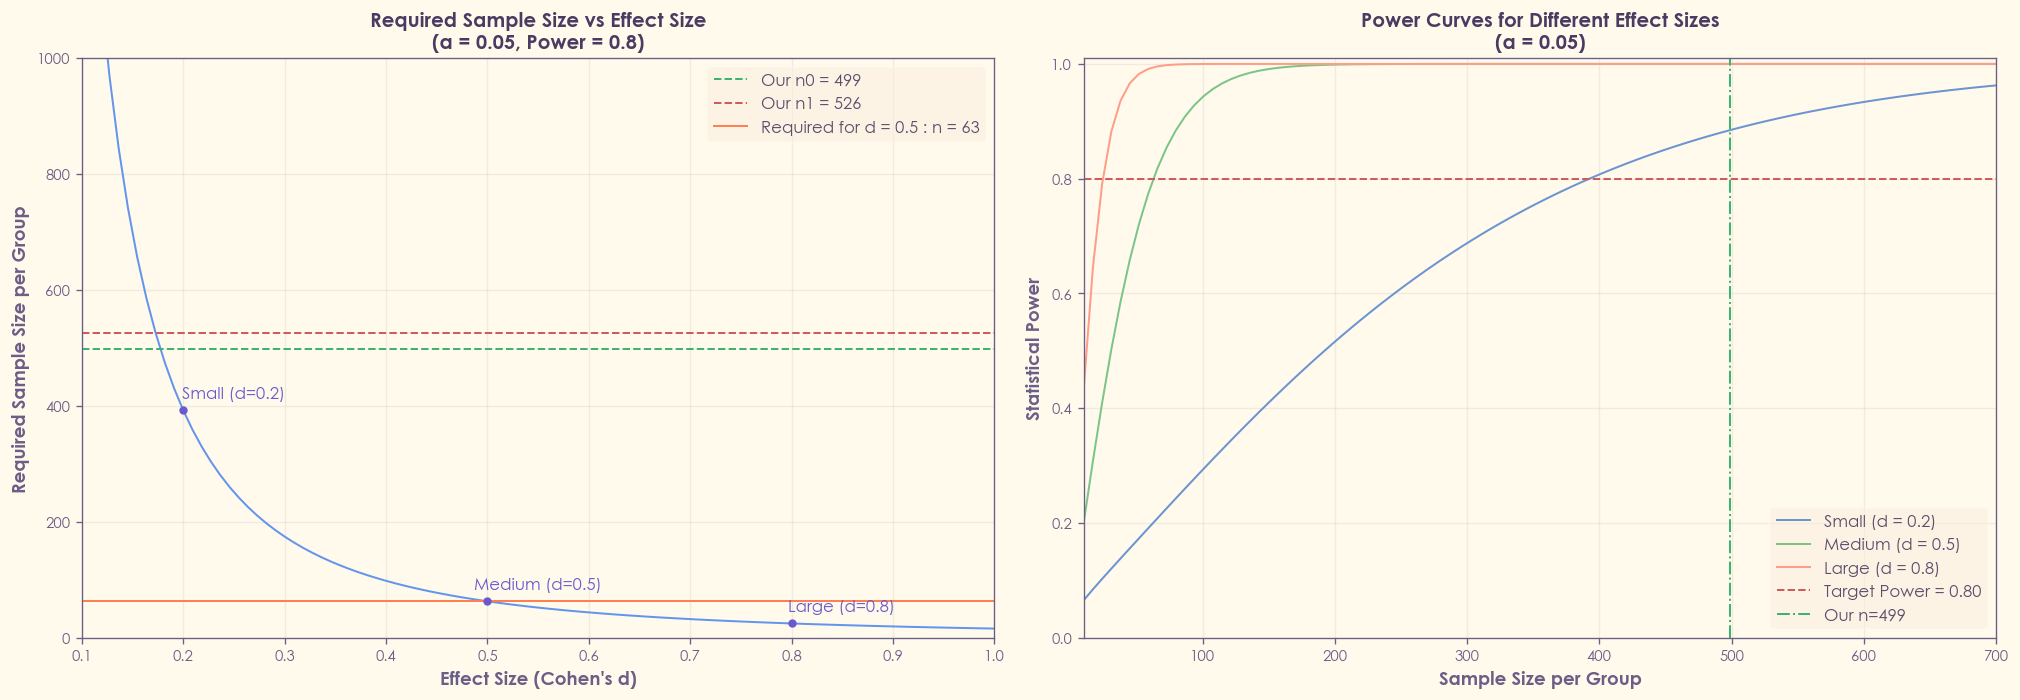

In [11]:
# Visualize Power Analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))

# Plot 1: Required sample size vs effect size
effect_range = np.linspace(0.1, 1.0, 100)
n_range = [2 * ((z_alpha_half + z_beta) / d) ** 2 for d in effect_range]

ax1.plot(effect_range, n_range, linewidth=1.2, color='cornflowerblue')

ax1.axhline(n_no_disease, color='mediumseagreen', linestyle='--', 
            label=f'Our n0 = {n_no_disease}', linewidth=1.2)
ax1.axhline(n_disease, color='indianred', linestyle='--', 
            label=f'Our n1 = {n_disease}', linewidth=1.2)
ax1.axhline(n_required_medium, color='coral', linestyle='-', 
            label=f'Required for d = 0.5 : n = {n_required_medium}', linewidth=1.2)

# Mark standard effect sizes
for effect_name, d in effect_sizes.items():
    n = required_samples[effect_name]
    ax1.plot(d, n, 'o', color='slateblue', markersize=4)
    ax1.annotate(effect_name, (d, n), textcoords="offset pixels", color='slateblue',
                 xytext=(50,12), ha='center', fontsize=10)

ax1.set_xlabel('Effect Size (Cohen\'s d)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Required Sample Size per Group', fontsize=11, fontweight='bold')
ax1.set_title(f'Required Sample Size vs Effect Size\n(α = {alpha}, Power = {power})', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=10)
ax1.set_xlim(0.1, 1.0)
ax1.set_ylim(0, 1000)

##########################

# Plot 2: Power vs sample size for different effect sizes
n_range_plot = np.linspace(10, 700, 100)
powers_small = [1 - norm.cdf(z_alpha_half - 0.2 * np.sqrt(n/2)) for n in n_range_plot]
powers_medium = [1 - norm.cdf(z_alpha_half - 0.5 * np.sqrt(n/2)) for n in n_range_plot]
powers_large = [1 - norm.cdf(z_alpha_half - 0.8 * np.sqrt(n/2)) for n in n_range_plot]

ax2.plot(n_range_plot, powers_small, label='Small (d = 0.2)', linewidth=1.2)
ax2.plot(n_range_plot, powers_medium, label='Medium (d = 0.5)', linewidth=1.2)
ax2.plot(n_range_plot, powers_large, label='Large (d = 0.8)', linewidth=1.2)
ax2.axhline(0.8, color='indianred', linestyle='--', label='Target Power = 0.80', linewidth=1.2)
ax2.axvline(min(n_no_disease, n_disease), color='mediumseagreen', linestyle='-.', 
            label=f'Our n={min(n_no_disease, n_disease)}', linewidth=1.2)

ax2.set_xlabel('Sample Size per Group', fontsize=11, fontweight='bold')
ax2.set_ylabel('Statistical Power', fontsize=11, fontweight='bold')
ax2.set_title(f'Power Curves for Different Effect Sizes\n(α = {alpha})', 
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right', fontsize=10)
ax2.set_xlim(10, 700)
ax2.set_ylim(0, 1.01)

plt.tight_layout()
#plt.savefig('../contents/figures/sophisticated/power_analysis.eps', bbox_inches='tight')
plt.show()

In [12]:
print("\n" + "="*35)
print("DESCRIPTIVE STATISTICS BY FEATURE")
print("="*35)

descriptive_stats = []

for feature in features:
    group0 = df[df['target'] == 0][feature]
    group1 = df[df['target'] == 1][feature]
    
    descriptive_stats.append({
        'Feature': feature,
        'No_Disease_Mean': group0.mean().round(4),
        'No_Disease_Median': group0.median(),
        'No_Disease_SD': group0.std().round(4),
        'Disease_Mean': group1.mean().round(4),
        'Disease_Median': group1.median(),
        'Disease_SD': group1.std().round(4),
        'Mean_Diff': group1.mean() - group0.mean().round(4),
        'Median_Diff': group1.median() - group0.median(),
        'Variability': (group1.std() - group0.std()).round(4)
    })

desc_df = pd.DataFrame(descriptive_stats)
desc_df


DESCRIPTIVE STATISTICS BY FEATURE


,Feature,No_Disease_Mean,No_Disease_Median,No_Disease_SD,Disease_Mean,Disease_Median,Disease_SD,Mean_Diff,Median_Diff,Variability
0,age,56.5691,58.0,7.9082,52.4087,52.0,9.6318,-4.160355,-6.0,1.7237
1,sex,0.8277,1.0,0.3781,0.5703,1.0,0.4955,-0.257358,0.0,0.1174
2,cp,0.4830,0.0,0.9080,1.3783,2.0,0.9459,0.895327,2.0,0.0379
3,trestbps,134.1062,130.0,18.5767,129.2452,130.0,16.1122,-4.860953,0.0,-2.4645
4,chol,251.2926,249.0,49.5589,240.9791,234.0,53.0103,-10.313513,-15.0,3.4514
5,fbs,0.1643,0.0,0.3709,0.1350,0.0,0.3420,-0.029319,0.0,-0.0289
6,restecg,0.4569,0.0,0.5448,0.5989,1.0,0.5021,0.141959,1.0,-0.0427
7,thalach,139.1303,142.0,22.5652,158.5856,161.5,19.0969,19.455251,19.5,-3.4683
8,exang,0.5491,1.0,0.4981,0.1350,0.0,0.3420,-0.414119,-1.0,-0.1561
9,oldpeak,1.6002,1.4,1.2910,0.5700,0.2,0.7711,-1.030238,-1.2,-0.5199


In [13]:
# Highlight features with large differences
large_diff = desc_df[abs(desc_df['Mean_Diff']) > desc_df['Mean_Diff'].std()]
large_variability = desc_df[abs(desc_df['Variability']) > desc_df['Variability'].std()]

print(f"\nFeatures with large mean differences:")
for _, row in large_diff.iterrows():
    print(f"  {row['Feature']}: Δ = {row['Mean_Diff']:.2f}")
print(f"\nFeatures with large Variability:")
for _, row in large_variability.iterrows():
    print(f"  {row['Feature']}: Δ = {row['Variability']:.2f}")

#desc_df.to_csv('../contents/tables/sophisticated/descriptive_statistics.csv', index=False)


Features with large mean differences:
  chol: Δ = -10.31
  thalach: Δ = 19.46

Features with large Variability:
  age: Δ = 1.72
  trestbps: Δ = -2.46
  chol: Δ = 3.45
  thalach: Δ = -3.47


#### Feature Disparity Analysis (EDA Insights)

This analysis flags features whose separation between the `Target=0` (No Disease) and `Target=1` (Disease) groups is unusually large, relative to the typical variation across all features (Δ > 1 standard deviation of all differences).

Features `chol & thalac` shows the central tendency (mean) of the two groups are far apart, suggesting a major shift in the feature value with disease. Features `age, trestbps, chol, thalach` shows that the disease status significantly changes the data's spread (standard deviation), indicating inconsistent behavior between groups.

In [14]:
print("\n" + "="*45)
print("NORMALITY TESTING (Shapiro-Wilk Normality Test)")
print("="*45)
print("  Testing if features follow normal distribution")
print("  Required for Pearson correlation; not required for Mann-Whitney/Spearman")
print(" -"*45)

normality_results = []

for feature in features:
    # Overall normality
    stat_all, p_all = shapiro(df[feature])
    
    # By group
    stat_0, p_0 = shapiro(df[df['target']==0][feature])
    stat_1, p_1 = shapiro(df[df['target']==1][feature])
    
    normality_results.append({
        'Feature': feature,
        'Overall_p': p_all,
        'Overall_Normal': 'Yes' if p_all > 0.05 else 'No',
        'Group0_p': p_0,
        'Group0_Normal': 'Yes' if p_0 > 0.05 else 'No',
        'Group1_p': p_1,
        'Group1_Normal': 'Yes' if p_1 > 0.05 else 'No'
    })

normality_df = pd.DataFrame(normality_results)

non_normal_count = (normality_df['Overall_Normal'] == 'No').sum()
print(f"\nNon-normal features: {non_normal_count}/13")

non_normal_features = normality_df[normality_df['Overall_Normal']=='No']['Feature'].tolist()
if non_normal_features:
    print(f"  Non-normal: {', '.join(non_normal_features)}")
else:
    print(f"  All the features are normally distributed!")

normality_df
#normality_df.to_csv('../contents/tables/sophisticated/normality_tests.csv', index=False)


NORMALITY TESTING (Shapiro-Wilk Normality Test)
  Testing if features follow normal distribution
  Required for Pearson correlation; not required for Mann-Whitney/Spearman
 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

Non-normal features: 13/13
  Non-normal: age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal


,Feature,Overall_p,Overall_Normal,Group0_p,Group0_Normal,Group1_p,Group1_Normal
0,age,5.038685e-09,No,1.835932e-09,No,7.323107e-05,No
1,sex,3.354400e-44,No,3.120826e-36,No,4.108908e-32,No
2,cp,1.057491e-34,No,4.403694e-33,No,2.103801e-21,No
3,trestbps,2.194234e-15,No,2.013979e-12,No,3.664326e-07,No
4,chol,4.000063e-18,No,2.997677e-04,No,2.999551e-18,No
5,fbs,5.468937e-49,No,1.745068e-36,No,2.790976e-38,No
6,restecg,4.592292e-40,No,1.656558e-29,No,2.058342e-31,No
7,thalach,1.550333e-11,No,3.625342e-04,No,2.346926e-09,No
8,exang,1.530397e-43,No,2.887825e-31,No,2.790976e-38,No
9,oldpeak,4.668547e-30,No,4.989781e-14,No,8.023276e-27,No


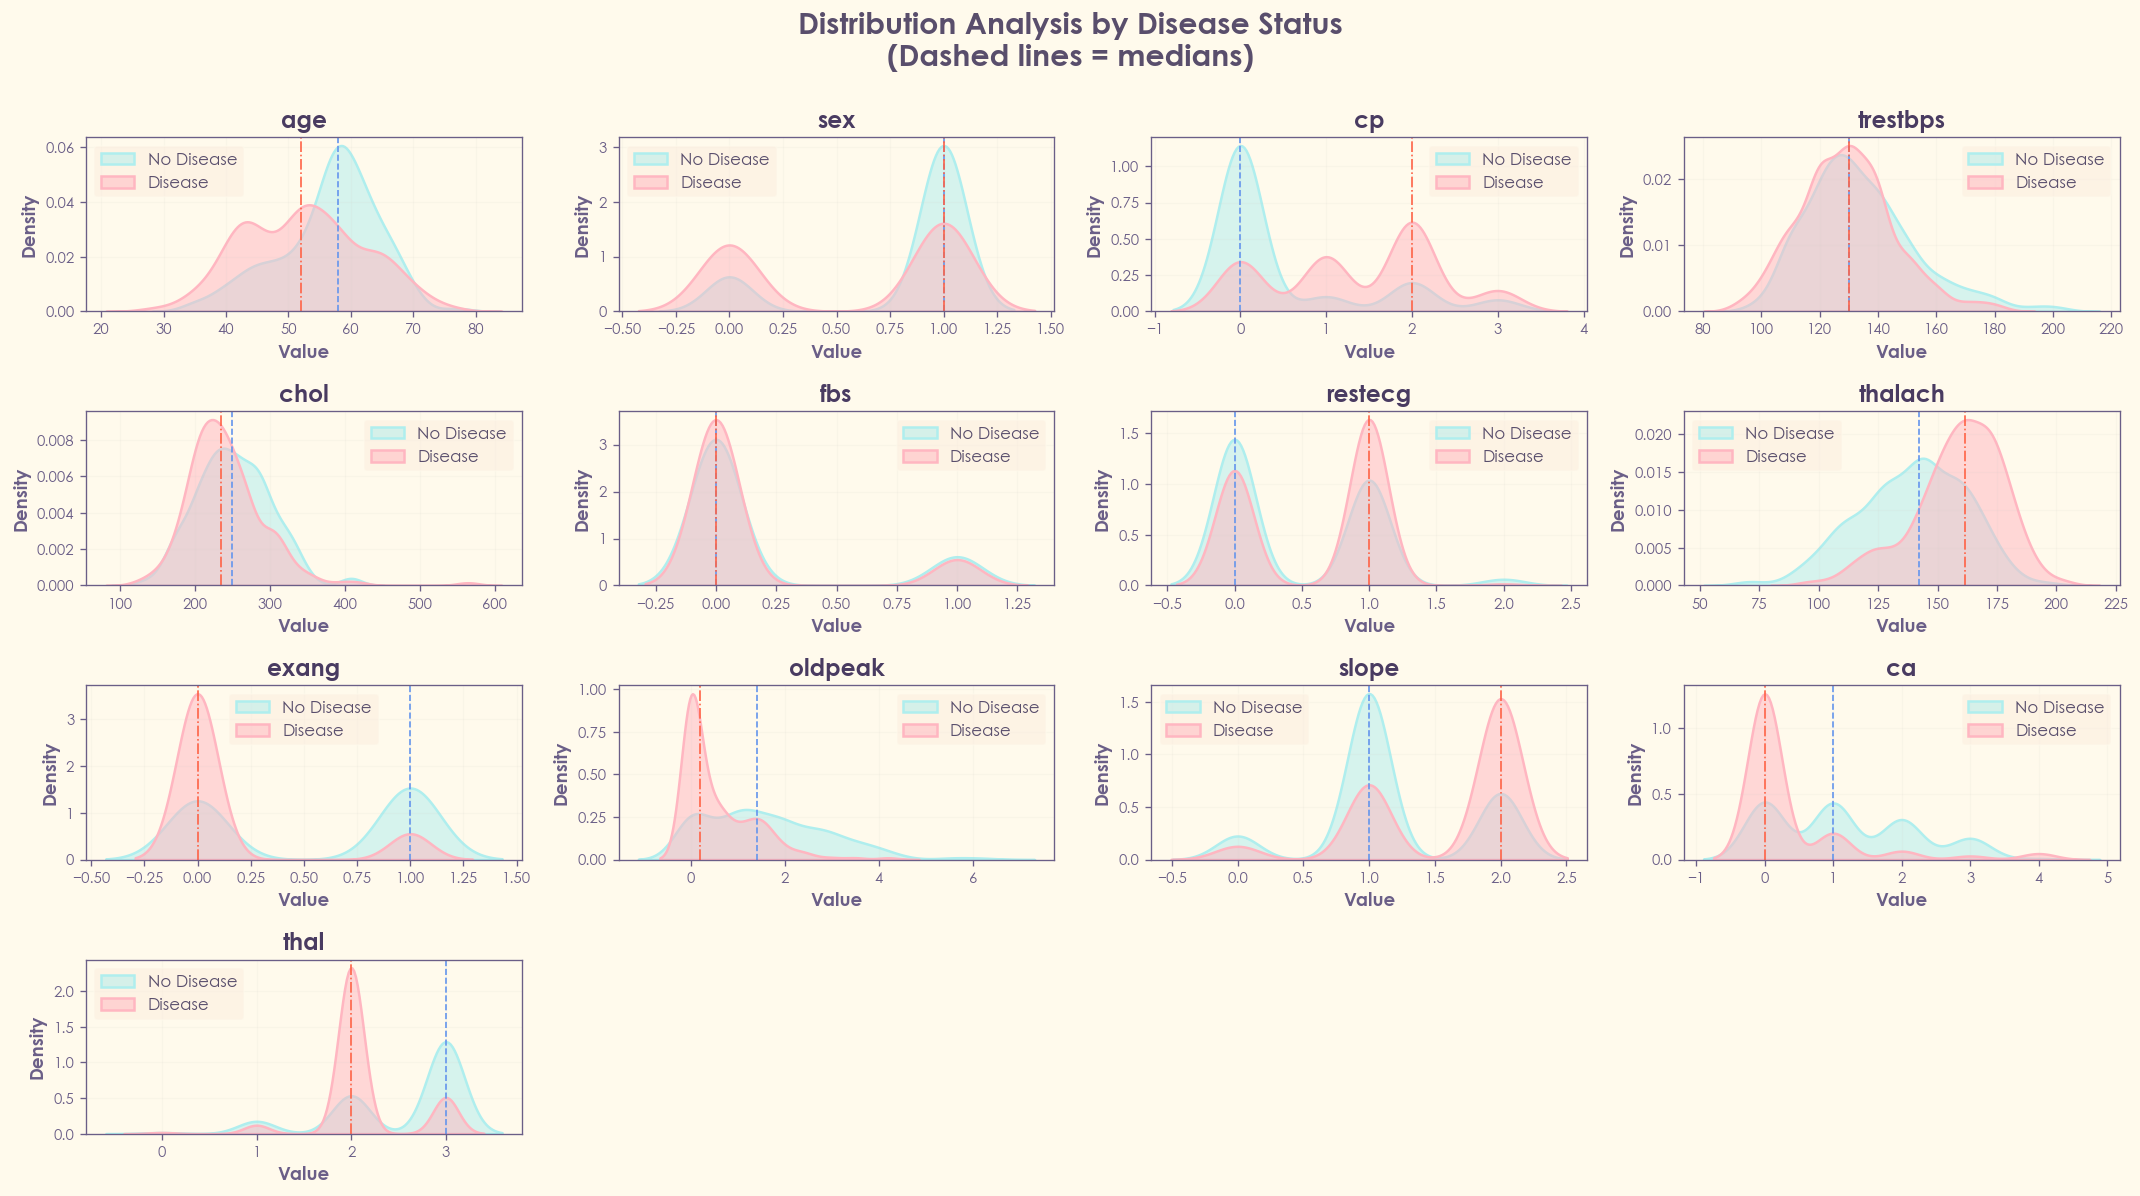

In [15]:
#Distribution visualization of features
fig, axes = plt.subplots(4, 4, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]

    # KDE plots for both groups
    sns.kdeplot(data=df[df['target'] == 0], x=feature, ax=ax,
                label='No Disease', color='paleturquoise', fill=True, alpha=0.5, linewidth=1.5)
    sns.kdeplot(data=df[df['target'] == 1], x=feature, ax=ax,
                label='Disease', color='lightpink', fill=True, alpha=0.5, linewidth=1.5)

    # Add median lines
    med0 = df[df['target'] == 0][feature].median()
    med1 = df[df['target'] == 1][feature].median()
    ax.axvline(med0, color='cornflowerblue', linestyle='--', linewidth=1, alpha=1)
    ax.axvline(med1, color='tomato', linestyle='-.', linewidth=1, alpha=1)

    ax.set_title(f'{feature}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Value', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=10, loc='best')
    ax.grid(alpha=0.1)

# Turn off the last two unused axes
axes[13].axis('off')
axes[14].axis('off')
axes[15].axis('off')

plt.suptitle('Distribution Analysis by Disease Status\n(Dashed lines = medians)', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
#plt.savefig('../contents/figures/sophisticated/distributions_by_group.eps', bbox_inches='tight')
plt.show()

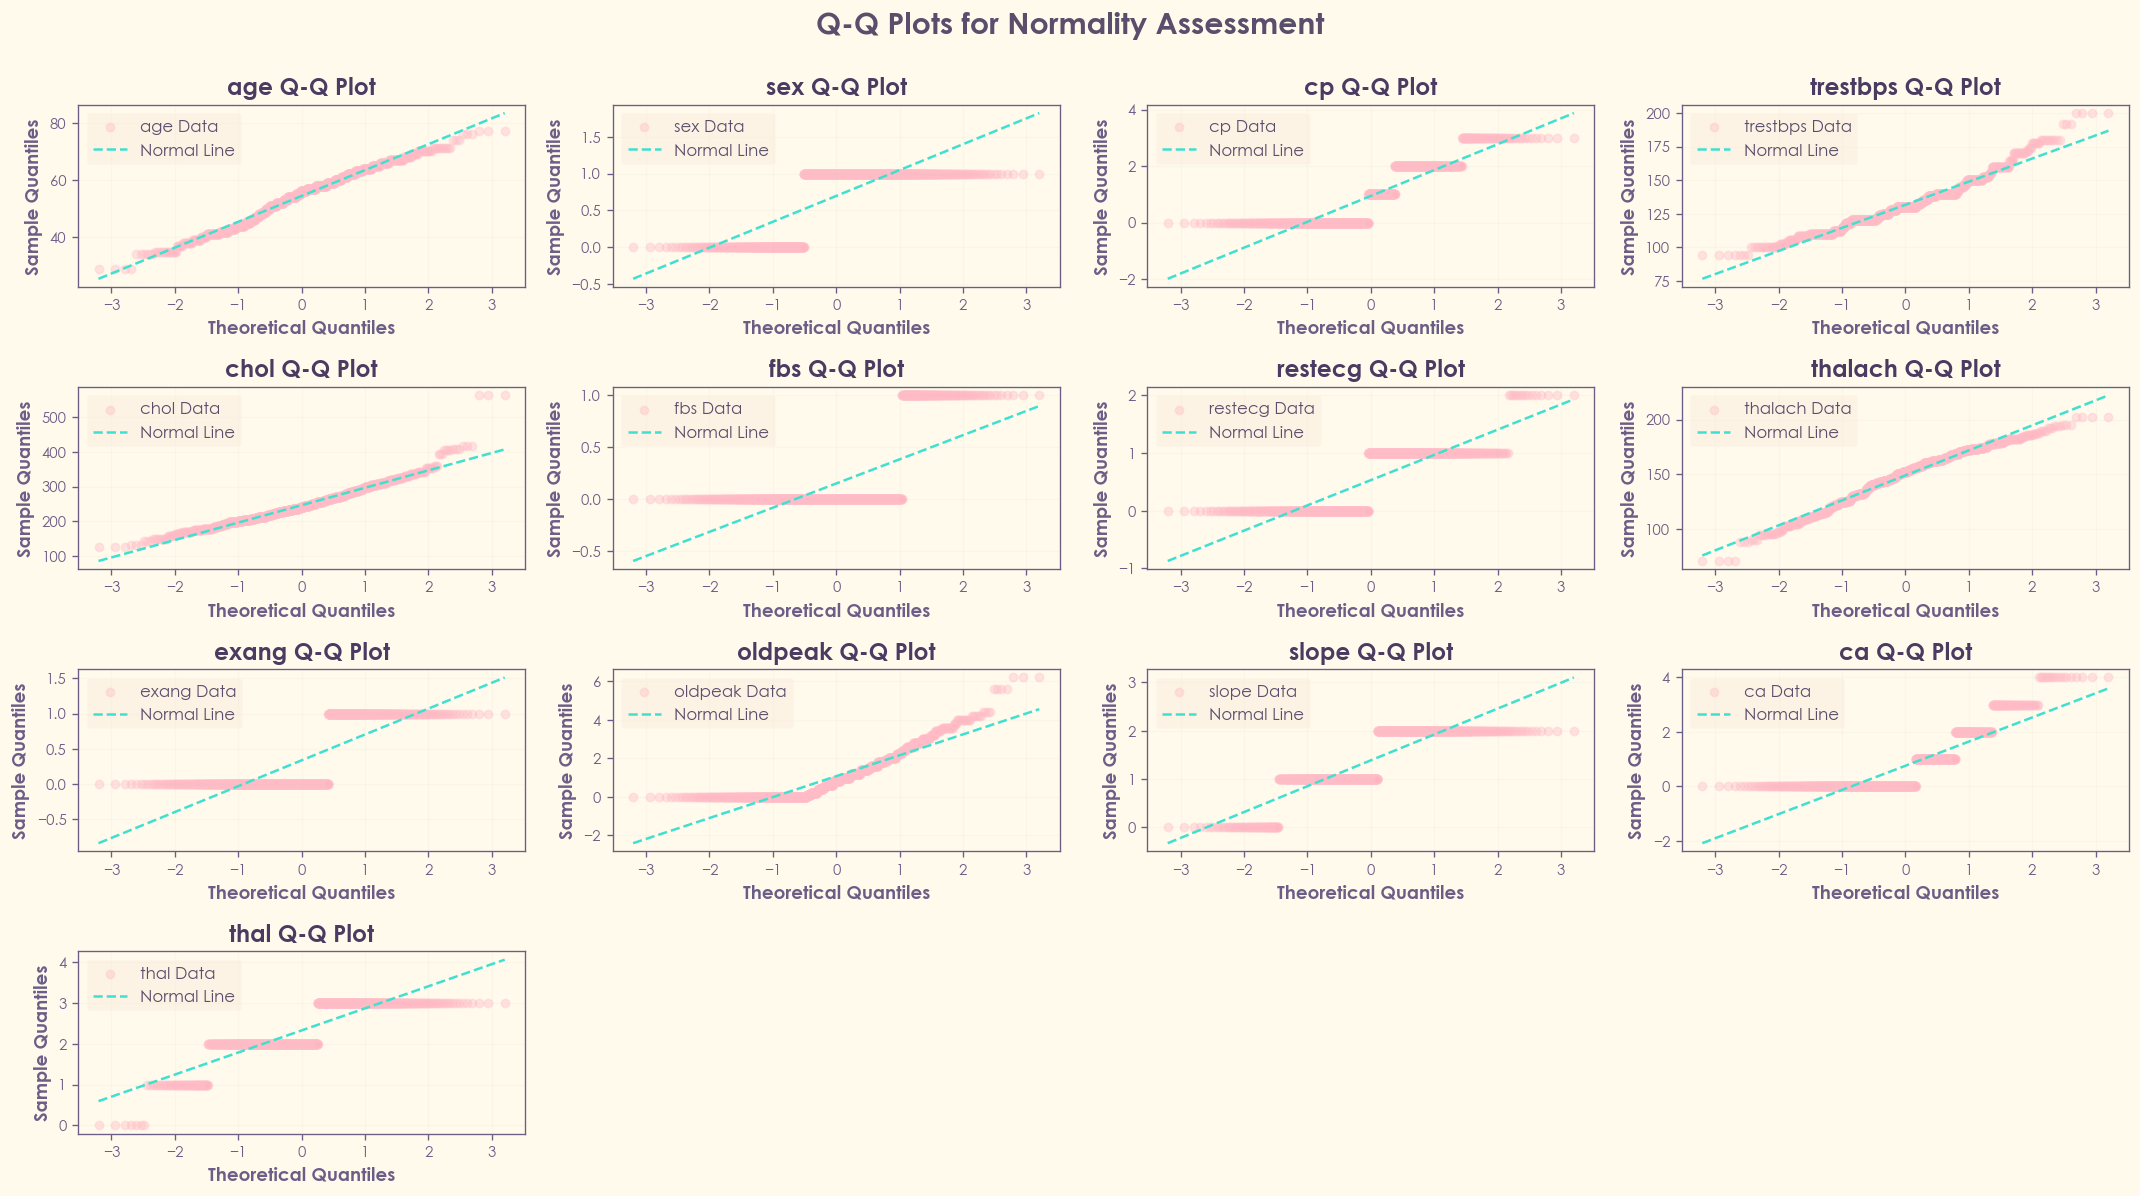

In [16]:
import scipy.stats as stats

fig, axes = plt.subplots(4, 4, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]

    # Get Q-Q data
    (osm, osr), (slope, intercept, r) = stats.probplot(df[feature], dist="norm")

    # Plot points
    ax.scatter(osm, osr, color='lightpink', edgecolor='pink', alpha=0.35, s=25, label=f'{feature} Data')

    # Plot reference line
    ax.plot(osm, slope * osm + intercept, color='turquoise', linestyle='--', linewidth=1.5, label='Normal Line')

    ax.set_title(f'{feature} Q-Q Plot', fontweight='bold', fontsize=14)
    ax.set_xlabel('Theoretical Quantiles', fontsize=11)
    ax.set_ylabel('Sample Quantiles', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.1)

# Turn off the last two unused axes
axes[13].axis('off')
axes[14].axis('off')
axes[15].axis('off')

plt.suptitle('Q-Q Plots for Normality Assessment', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
#plt.savefig('../contents/figures/sophisticated/qq_plots.eps', bbox_inches='tight')
plt.show()

#### Normality Assumption
The Shapiro-Wilk test and Q-Q plots confirm that **all 13 features are non-normally distributed.**

**Why this matters?**
1. Pearson Correlation is Invalid. It measures linear relationships, that relies on the assumption of normality for its test of significance. Its use with this dataset risks the `Type I error` inflation (false positives) and unreliable p-values.
2. So non-parametric tests are required for this dataset. Like, t-test, Mann-Whitney test, and Spearman rank correlation.

In [17]:
print("\n" + "="*25)
print("OUTLIER DETECTION")
print("="*25)

outlier_summary = []

for feature in features:
    data = df[feature]
    
    # IQR method
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_iqr = ((data < lower_bound) | (data > upper_bound)).sum()
    outlier_pct = (outliers_iqr / len(data)) * 100
    
    # Z-score method
    z_scores = np.abs(stats.zscore(data))
    outliers_z = (z_scores > 3).sum()
    
    outlier_summary.append({
        'Feature': feature,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Outliers_IQR': outliers_iqr,
        'Outliers_Zscore': outliers_z,
        'Outlier_Pct': outlier_pct
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df


OUTLIER DETECTION


,Feature,Q1,Q3,IQR,Outliers_IQR,Outliers_Zscore,Outlier_Pct
0,age,48.0,61.0,13.0,0,0,0.000000
1,sex,0.0,1.0,1.0,0,0,0.000000
2,cp,0.0,2.0,2.0,0,0,0.000000
3,trestbps,120.0,140.0,20.0,30,7,2.926829
4,chol,211.0,275.0,64.0,16,13,1.560976
5,fbs,0.0,0.0,0.0,153,0,14.926829
6,restecg,0.0,1.0,1.0,0,0,0.000000
7,thalach,132.0,166.0,34.0,4,4,0.390244
8,exang,0.0,1.0,1.0,0,0,0.000000
9,oldpeak,0.0,1.8,1.8,7,7,0.682927


In [18]:
features_with_outliers = outlier_df[outlier_df['Outliers_IQR'] > 0]['Feature'].tolist()
print(f"\nFeatures with outliers ({len(features_with_outliers)}/13): {', '.join(features_with_outliers)}")

#outlier_df.to_csv('../contents/tables/sophisticated/outlier_analysis.csv', index=False)


Features with outliers (7/13): trestbps, chol, fbs, thalach, oldpeak, ca, thal


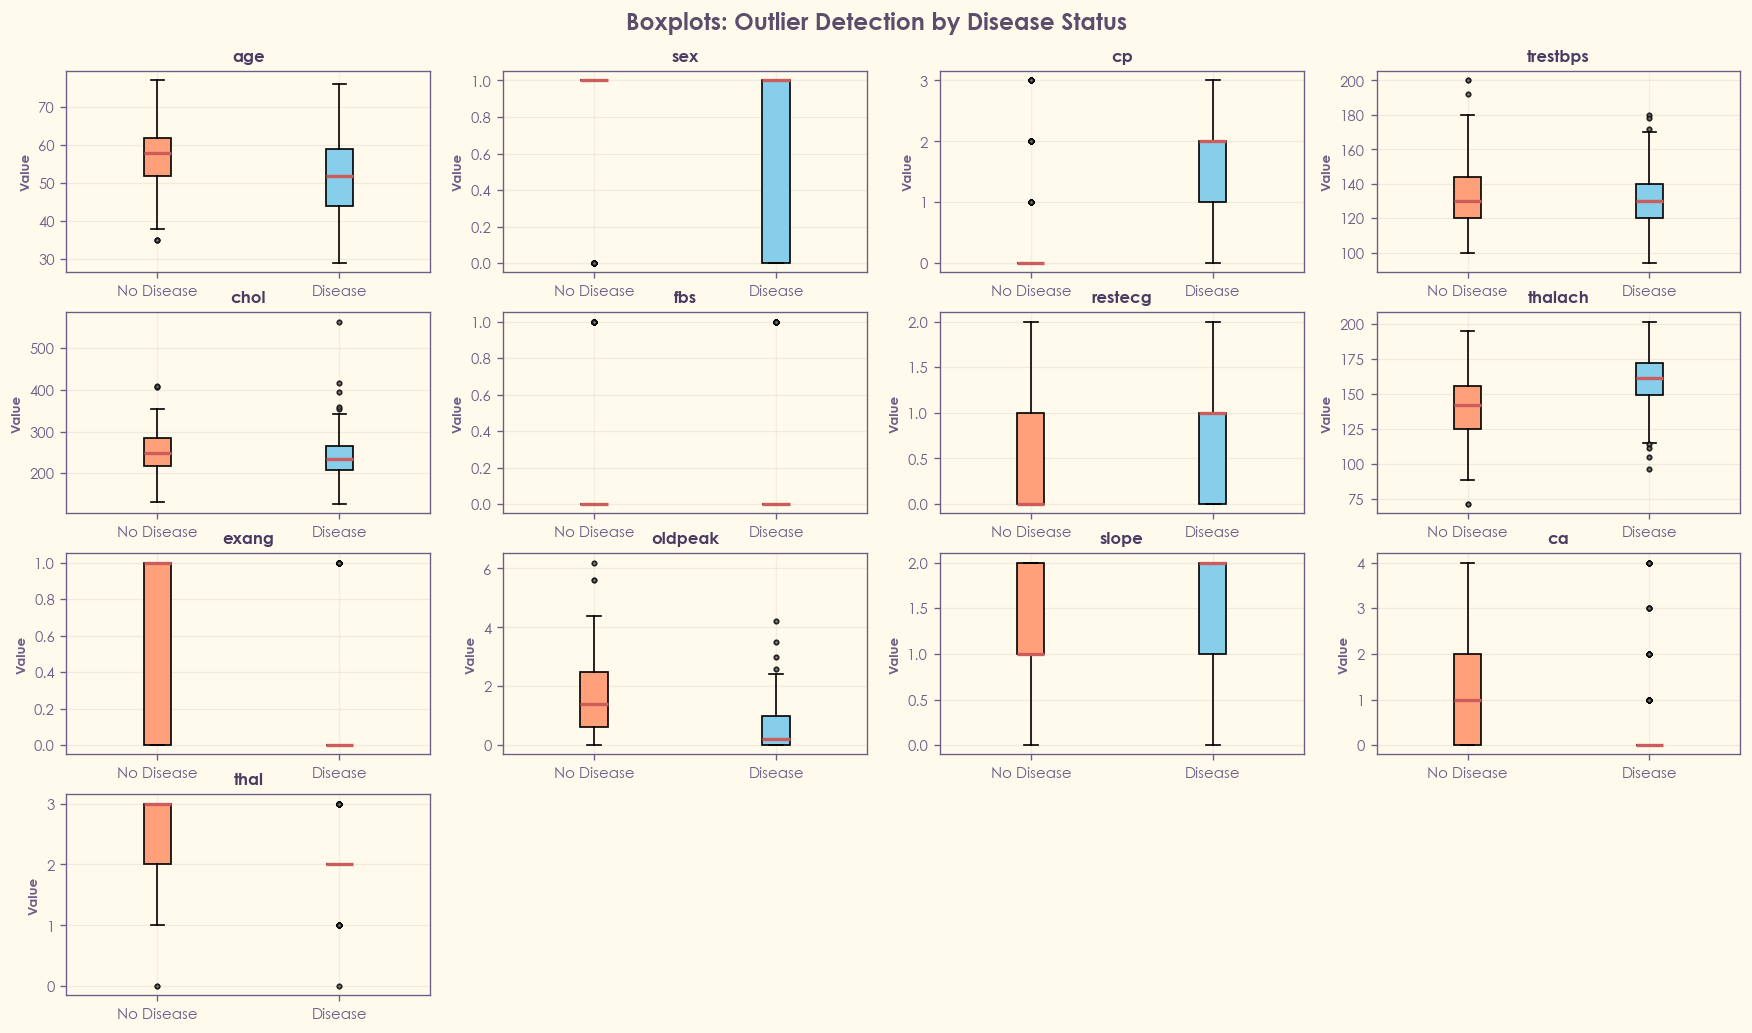

In [19]:
#outlier detection using boxplots
fig, axes = plt.subplots(4, 4, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]
    data_list = [df[df['target'] == 0][feature], df[df['target'] == 1][feature]]
    bp = ax.boxplot(data_list, labels=['No Disease', 'Disease'], patch_artist=True,
                    medianprops=dict(color='indianred', alpha=1, linewidth=2),
                    boxprops=dict(linewidth=1),
                    whiskerprops=dict(linewidth=1),
                    capprops=dict(linewidth=1),
                    flierprops=dict(marker='.', markersize=5, alpha=0.5, markerfacecolor='gray'))

    bp['boxes'][0].set_facecolor('lightsalmon')  # No Disease
    bp['boxes'][1].set_facecolor('skyblue')      # Disease

    ax.set_title(f'{feature}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Value', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Turn off the last unused subplot
axes[13].axis('off')
axes[14].axis('off')
axes[15].axis('off')

plt.suptitle('Boxplots: Outlier Detection by Disease Status', 
             fontsize=14, fontweight='bold', y=0.93)
#plt.savefig('../contents/figures/sophisticated/boxplots_outliers.eps', bbox_inches='tight')
plt.show()


MULTICOLLINEARITY ANALYSIS
Checking if features are highly correlated with each other.
High multicollinearity can inflate ML feature importance
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


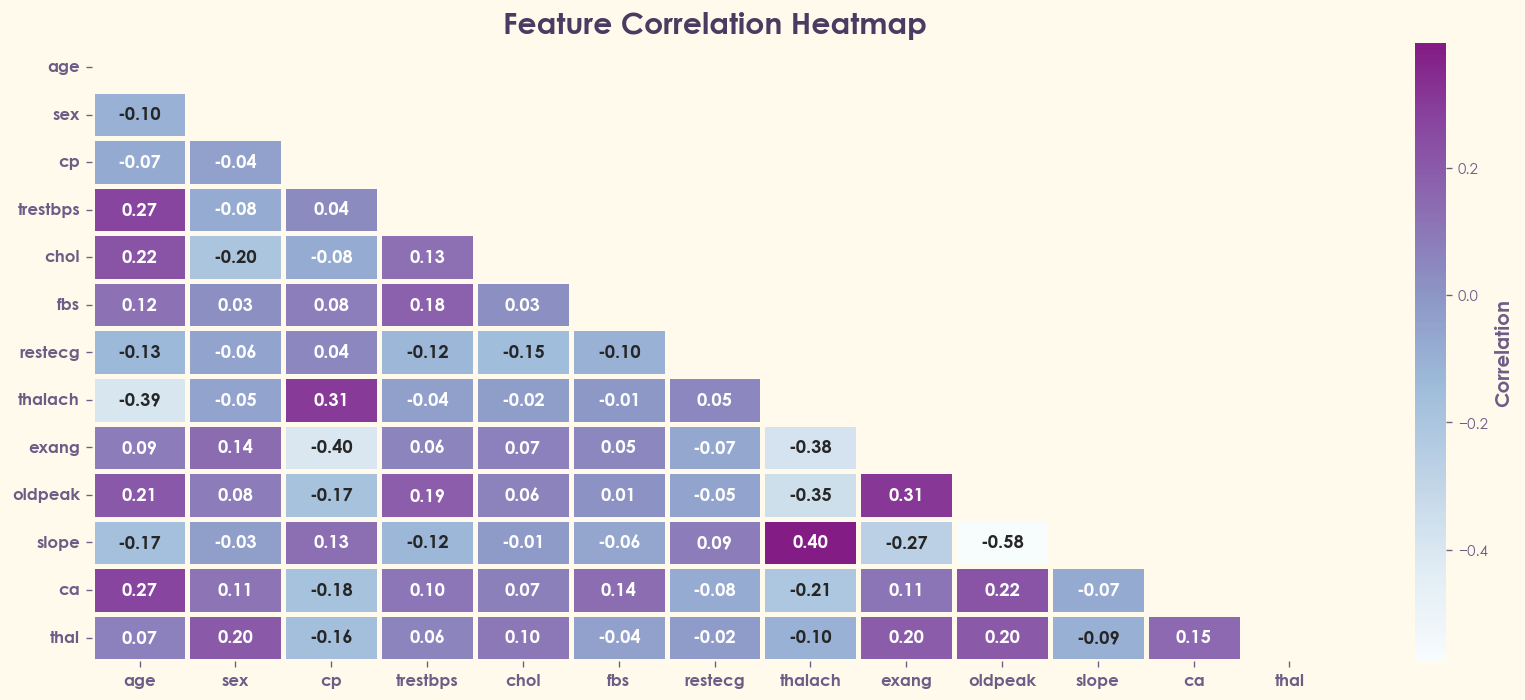

In [20]:
print("\n" + "="*45)
print("MULTICOLLINEARITY ANALYSIS")
print("="*45)
print("Checking if features are highly correlated with each other.\nHigh multicollinearity can inflate ML feature importance")
print("- "*45)

# Compute correlation matrix
corr_matrix = df[features].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot
plt.figure(figsize=(14, 6))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='BuPu',
            center=0, square=False,
            linewidths=3, linecolor='#fffaec',
            annot_kws={"size": 11, "weight": "bold"},
            cbar_kws={"shrink": 1, "label": "Correlation"})

plt.title('Feature Correlation Heatmap', fontsize=18, fontweight='bold')
plt.grid(False)
plt.xticks(rotation=0, fontsize=10, fontweight='bold')
plt.yticks(rotation=0, fontsize=10, fontweight='bold')
plt.tight_layout()
#plt.savefig('../contents/figures/sophisticated/correlation_matrix.eps', bbox_inches='tight')
plt.show()

In [21]:
#findf high correlations
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature1': corr_matrix.columns[i],
                'Feature2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"High Correlation Pairs: {len(high_corr_pairs)}")
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print("\n High correlations detected (|r| > 0.7):")
    print(high_corr_df.to_string(index=False))
else:
    print("No severe multi co-llinearity (all |r| < 0.7)")

High Correlation Pairs: 0
No severe multi co-llinearity (all |r| < 0.7)


**VIF - Variance Inflation Factor:** 
A statistical tool used to detect multicollinearity, or when independent variables in a regression model are highly correlated with each other.

In [22]:
# VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = features
vif_data["VIF"] = [variance_inflation_factor(df[features].values, i) for i in range(len(features))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVariance Inflation Factor (VIF):")
print("\tVIF < 5: Low multicollinearity ")
print("\t5-10: Moderate ")
print("\tVIF > 10: High multicollinearity")
print("-"*45)

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\nHigh VIF features:")
else:
    print("\nAll features have acceptable VIF (<10)")

vif_data


Variance Inflation Factor (VIF):
	VIF < 5: Low multicollinearity 
	5-10: Moderate 
	VIF > 10: High multicollinearity
---------------------------------------------

High VIF features:


,Feature,VIF
3,trestbps,57.953085
7,thalach,42.598372
0,age,38.699830
4,chol,26.185961
12,thal,16.724068
10,slope,9.854424
1,sex,3.613725
9,oldpeak,3.117289
2,cp,2.376553
8,exang,2.073879


In [23]:
#vif_data.to_csv('../contents/tables/sophisticated/vif_multicollinearity.csv', index=False)

#### Feature Collinearity and Variance Assessment
The correlation heatmap provides the pairwise correlation coefficient, r for every feature combination. It confirmed no severe pairwise multicollinearity (all absolute correlations were less than 0.7). This suggests that, individually, no two features are measuring the exact same information.

The analysis identified critical multicollinearity in several features (`e.g., trestbps, thalach, age, chol, thal`), with VIF values significantly exceeding the threshold of 10. Although the high VIF does not impact the current feature significance tests (Mann-Whitney U-test), it is a major flag for future modeling. If a linear model (like Logistic Regression) is used, these features will lead to highly unstable coefficient estimates and reduced model interpretability.

## Doing STATS Correctly
1. Assumption Validations: Mann-Whitney U tests, Chi-square tests, and Correlation Assumption Validation
2. Multiple Correction Tests: Bondferroni correction
3. Calculate Effect Sizes (MISSING IN ORIGINAL)
4. Calculate Confidence Intervals (MISSING IN ORIGINAL)

### 4.1 Mann-Whitney U-test Assumption Validation

```
Mann-Whitney U Test Assumptions:
    1. Independence of observations (patients are unique)
    2. Ordinal or continuous dependent variable (all features qualify)
    3. Distribution shapes between groups

INTERPRETATION DEPENDS ON DISTRIBUTION SHAPES:
    - If shapes are SIMILAR --> Mann-Whitney tests for MEDIAN differences
    - If shapes DIFFER --> Mann-Whitney tests for STOCHASTIC DOMINANCE (one group tends to have higher values)
```

###### Hypotheses for Mann-Whitney U-Test (Group Comparison):
- $H_0^{(Null Hypothesis)}$: The distribution of the feature being tested is identical for patients with heart disease (`Target=1`) and patients without heart disease (`Target=0`).
- $H_1^{(Alternative Hypothesis)}$: The distribution of the feature being tested is significantly different between the patients with heart disease and those without.

*Note: This test is most appropriate for features like `age, trestbps, chol, thalach, oldpeak, ca, and thal` to compare their central tendency and spread between the groups.*


In [24]:
# Load naive reproduction results of the original paper
table2_naive = pd.read_csv('../contents/tables/reproduced/table2_reproduced.csv')

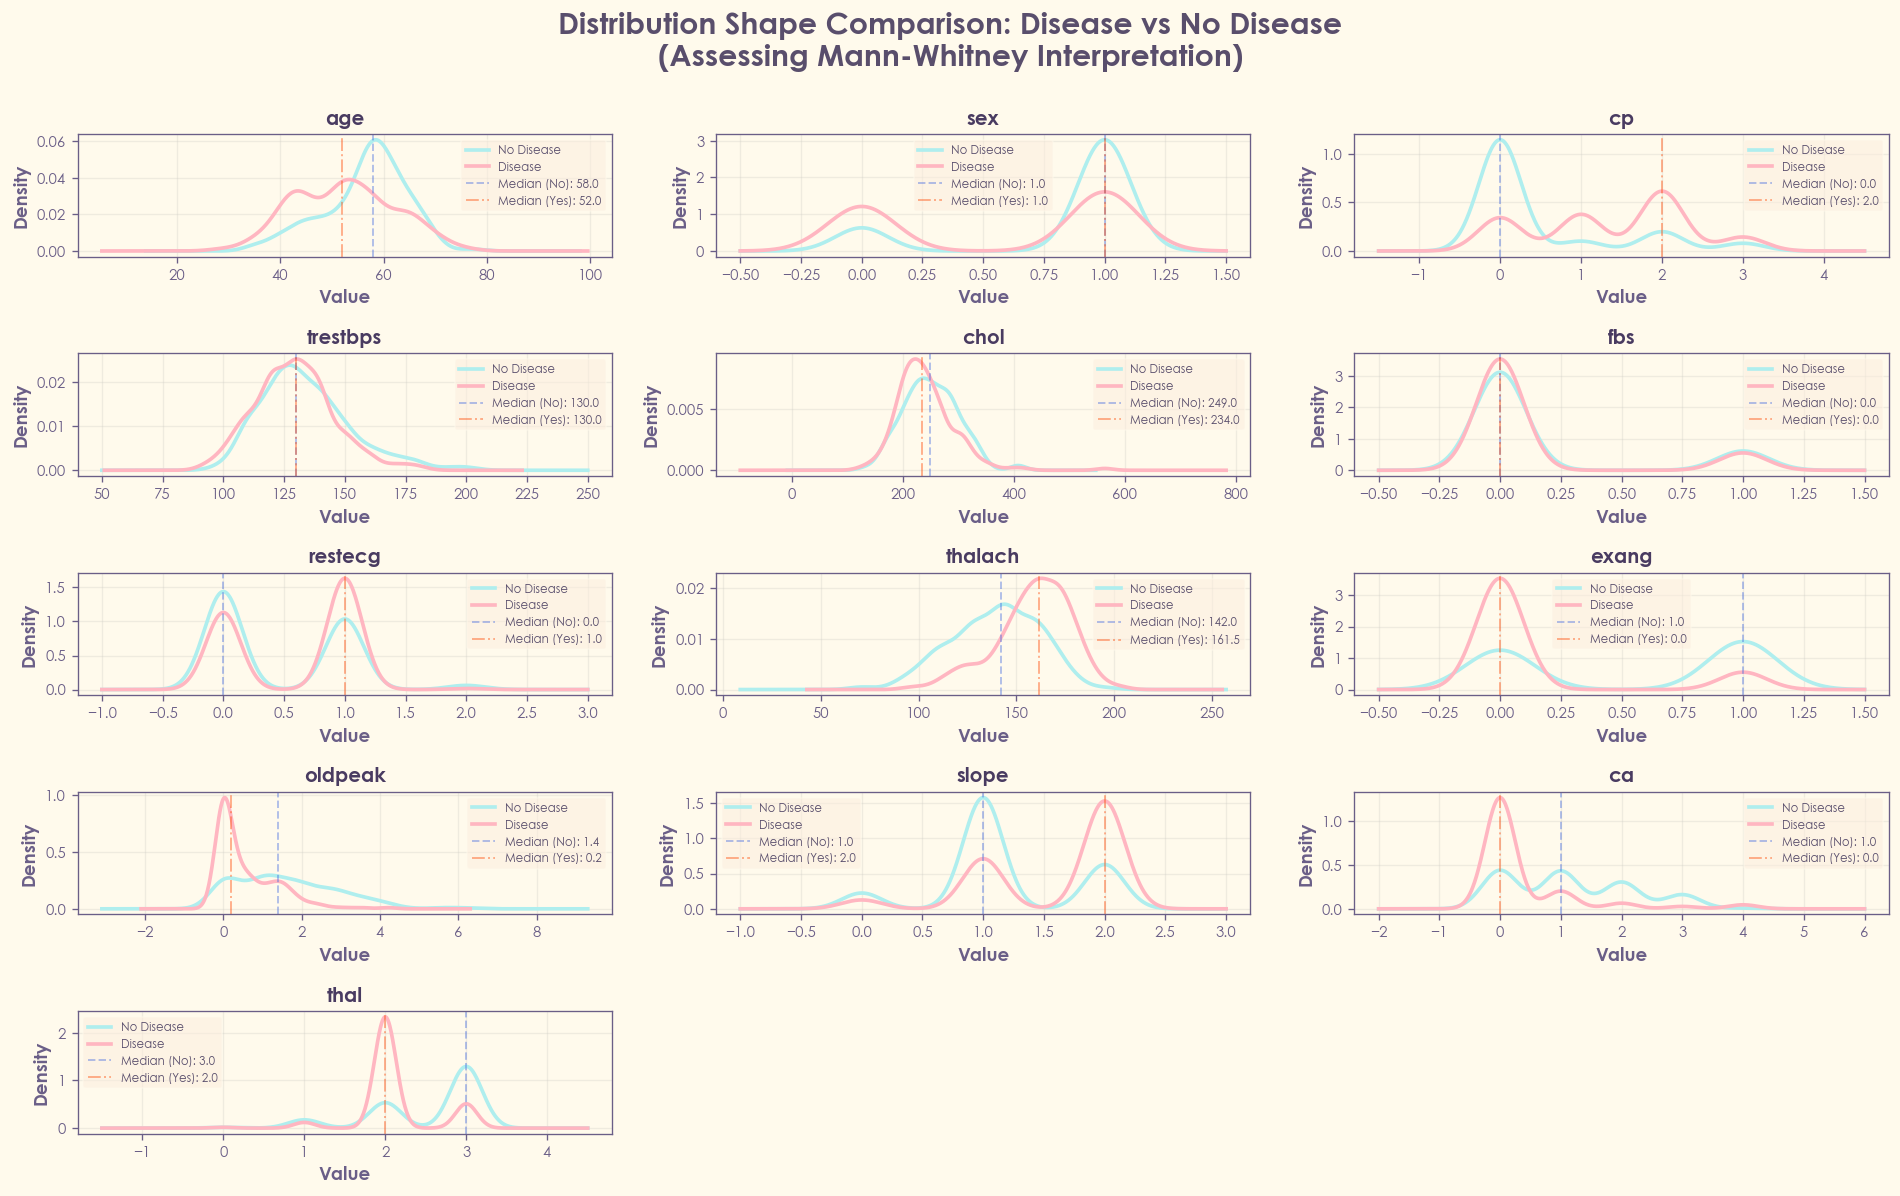

In [25]:
## Assessing Visual distriibution shape similarrity
shape_assessment = []

fig, axes = plt.subplots(5, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]
    
    group0 = df[df['target'] == 0][feature]
    group1 = df[df['target'] == 1][feature]
    
    # Kernel Density Estimation (KDE) for smoothed histogram
    group0.plot.kde(ax=ax, label='No Disease', linewidth=2.2, color='paleturquoise')
    group1.plot.kde(ax=ax, label='Disease', linewidth=2.2, color='lightpink')
    
    # Add medians
    med0, med1 = group0.median(), group1.median()
    ax.axvline(med0, color='royalblue', linestyle='--', linewidth=1.2, alpha=0.4, label=f'Median (No): {med0:.1f}')
    ax.axvline(med1, color='orangered', linestyle='-.', linewidth=1.2, alpha=0.4, label=f'Median (Yes): {med1:.1f}')
    
    ax.set_title(f'{feature}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Value', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=7, loc='best')
    ax.grid(alpha=0.3)
    
    # Assess shape similarity wiuth Simple heuristic: compare skewness
    skew0 = group0.skew()
    skew1 = group1.skew()
    skew_diff = abs(skew0 - skew1)
    
    # Assess if shapes are similar
    similar_shape = skew_diff < 0.5
    
    shape_assessment.append({
        'Feature': feature,
        'Skewness_No_Disease': skew0,
        'Skewness_Disease': skew1,
        'Skewness_Difference': skew_diff,
        'Similar_Shape': 'Yes' if similar_shape else 'No',
        'Median_No_Disease': med0,
        'Median_Disease': med1,
        'Median_Difference': med1 - med0
    })

# Remove extra subplots
for idx in range(len(features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribution Shape Comparison: Disease vs No Disease\n(Assessing Mann-Whitney Interpretation)', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
#plt.savefig('../contents/figures/sophisticated/distribution_shapes_mann_whitney.eps', bbox_inches='tight')
plt.show()

In [26]:
## Assessing Quantitative Shape Similarity

shape_df = pd.DataFrame(shape_assessment)
print("\nSkewness Comparison:")
print(shape_df[['Feature', 'Skewness_No_Disease', 'Skewness_Disease', 
               'Skewness_Difference', 'Similar_Shape']].to_string(index=False))

similar_count = (shape_df['Similar_Shape'] == 'Yes').sum()
similar_shapes = shape_df[shape_df['Similar_Shape'] == 'Yes']['Feature'].tolist()

print(f"\nFeatures counts similar distribution shapes: {similar_count}/13")
print(f"Features with Similar shapes: {', '.join(similar_shapes)}\n")

dissimilar_features = shape_df[shape_df['Similar_Shape'] == 'No']['Feature'].tolist()
dissimilar_count = (shape_df['Similar_Shape'] == 'No').sum()
if dissimilar_features:
    print(f"Features counts different shapes: {dissimilar_count}/13")
    print(f"Features with different shapes: {', '.join(dissimilar_features)}")

print("\n======MEDIAN DIFFERENCES======")
print(shape_df[['Feature', 'Median_No_Disease', 'Median_Disease', 'Median_Difference']].round(4).to_string(index=False))


Skewness Comparison:
 Feature  Skewness_No_Disease  Skewness_Disease  Skewness_Difference Similar_Shape
     age            -0.573951          0.100256             0.674207            No
     sex            -1.740332         -0.285009             1.455323            No
      cp             1.626143         -0.127876             1.754019            No
trestbps             0.890530          0.417168             0.473361           Yes
    chol             0.322571          1.720794             1.398223            No
     fbs             1.817098          2.142583             0.325484           Yes
 restecg             0.620485         -0.268300             0.888785            No
 thalach            -0.306664         -0.670236             0.363572           Yes
   exang            -0.197942          2.142583             2.340525            No
 oldpeak             0.709913          1.652488             0.942575            No
   slope             0.002934         -1.146172             1.149

In [27]:
# Identify large median differences
large_diff_threshold = shape_df['Median_Difference'].abs().std()
large_diff = shape_df[shape_df['Median_Difference'].abs() > large_diff_threshold]

print(f"Features with large median differences (|Δ| > {large_diff_threshold:.2f}):")
for _, row in large_diff.iterrows():
    direction = "higher" if row['Median_Difference'] > 0 else "lower"
    print(f"\t{row['Feature']}: {direction} in disease group (Δ = {row['Median_Difference']:.2f})")

# Save
#shape_df.to_csv('../contents/tables/sophisticated/mann_whitney_shape_assessment.csv', index=False)

Features with large median differences (|Δ| > 6.25):
	chol: lower in disease group (Δ = -15.00)
	thalach: higher in disease group (Δ = 19.50)


#### **The Critical Question About Mann-Whitney U Test**

While visual inspection of distribution shapes and skewness comparison provide intuitive understanding, we need a **formal statistical test** to rigorously assess whether the distributions of the two groups (disease vs. no disease) have the same shape. The interpretation of Mann-Whitney U test results **depends critically on distribution shapes**. Key Findings from Distribution Shapes are:

1. **Large Median Shifts (|Δ| > 1):**
```
thalach:  +19.5 (Disease group has much higher max heart rate)
chol:     -15.0 (Disease group has lower cholesterol - unexpected!)  <---------|
age:      -6.0  (Disease group is younger - unexpected!)             <---------|
cp:       +2.0  (Disease group has more severe chest pain)
oldpeak:  -1.2  (Disease group has less ST depression)
```

2. **No or Minimal Median Difference (|Δ| ≤ 0.5):**
```
trestbps:  0.0  (Blood pressure medians identical!)
fbs:       0.0  (Fasting blood sugar medians identical!)
sex:       0.0  (Gender distribution identical!)
```

3. The negative median differences for age and cholesterol are **counterintuitive** - I'd expect diseased patients to be older and have higher cholesterol. This suggests:
    - The "disease" label may include different stages or types
    - The dataset may have sampling bias
    - Other factors (like thalach, cp) are stronger predictors
    
##### **What's next?**

The plots show some features with similar medians despite shape difference and vice versa. Now, to formally determine **statistical significance despite the shape difference**, I will be utilizing the **Kolmogorov-Smirnov Test** [3,4,5]. So that I could answer,
 - Are the observed shape differences statistically significant?
 - Whhich interpretation framework should we use for Mann-Whitney results?
 - Can we trust median comparisons, or we must use stochastic dominance interpretation?

In [28]:
print("K-S Test Hypothesis: If two distributions are identical or not")
print("\tH0: Distributions have same shape")
print("\tH1: Distributions differ in shape")

K-S Test Hypothesis: If two distributions are identical or not
	H0: Distributions have same shape
	H1: Distributions differ in shape


In [29]:
print("\n" + "-"*55)
print("KOLMOGOROV-SMIRNOV TEST (Distribution Shape Equality)")
print("-"*55)

from scipy.stats import ks_2samp

ks_results = []

for feature in features:
    group0 = df[df['target'] == 0][feature]
    group1 = df[df['target'] == 1][feature]
    
    ks_stat, ks_p = ks_2samp(group0, group1)
    
    ks_results.append({
        'Feature': feature,
        'KS_Statistic': ks_stat,
        'KS_p_value': ks_p,
        'Same_Distribution': 'No' if ks_p < 0.05 else 'Yes'
    })

ks_df = pd.DataFrame(ks_results)
ks_df


-------------------------------------------------------
KOLMOGOROV-SMIRNOV TEST (Distribution Shape Equality)
-------------------------------------------------------


,Feature,KS_Statistic,KS_p_value,Same_Distribution
0,age,0.287929,3.161561e-19,No
1,sex,0.257313,2.072054e-15,No
2,cp,0.519564,1.171228e-63,No
3,trestbps,0.114293,2.223405e-03,No
4,chol,0.160648,3.006475e-06,No
5,fbs,0.029348,9.735556e-01,Yes
6,restecg,0.160290,3.189279e-06,No
7,thalach,0.411347,2.507128e-39,No
8,exang,0.414117,7.191056e-40,No
9,oldpeak,0.419779,5.450554e-41,No


In [30]:
same_dist = (ks_df['Same_Distribution'] == 'Yes').sum()
same_dist_features = ks_df[ks_df['Same_Distribution'] == 'Yes']['Feature'].tolist()

print(f"Number of Features with similar distrribution: {same_dist}")
print(f"Features: {', '.join(same_dist_features)}")

#ks_df.to_csv('../contents/tables/sophisticated/kolmogorov_smirnov_tests.csv', index=False)

Number of Features with similar distrribution: 1
Features: fbs


**12 out of 13 features show significantly different distributions (p < 0.05)**. Only **fbs (fasting blood sugar)** shows no significant distributional difference (p = 0.974), confirming the paper's key finding that fbs is not associated with heart disease. This is EXPECTED!

**CONCLUSION:**
   - Mann-Whitney U test is APPROPRIATE (doesn't require identical distributions)
   - Interpretation: Tests if one group TENDS to have higher values
   
 #### Final Assumption about Mann-Whitney U test
 - ASSUMPTION 1: Independence of Observations is satistfied as each patient is a unique observation.
 - ASSUMPTION 2: Ordinal or Continuous Data, which it is
 - ASSUMPTION 3: Similar Sample Sizes (for power) are satisfied. n0=499, n1=526 (well-balanced, ratio=0.95)
 - ASSUMPTION 4: Distribution Shapes differ between groups (confirmed from K-S Test)
 
 Therefore,
 ##### Mann-Whitney U test is APPROPRIATE and VALID for this data

### 4.2 Chi-square Test Assumption Validation

###### Hypotheses for Chi-Square Test (Association/Independence):
- $H_0^{(Null Hypothesis)}$: There is no statistically significant association between the feature being tested (`e.g., sex, age`) and the presence of heart disease (`Target=1`). The variables are independent.
- $H_1^{(Alternative Hypothesis)}$: There is a statistically significant association between the feature being tested and the presence of heart disease. The variables are dependent.

*Note: This is the appropriate test for purely discrete/categorical features like `sex, cp, fbs, restecg, exang, and slope`.*

In [31]:
print("EXPECTED FREQUENCY VALIDATION")
print("-"*30)

chi_square_validation = []

for feature in features:
    # Create contingency table
    contingency = pd.crosstab(df[feature], df['target'])
    
    # Perform chi-sqr to get expected frequencies
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # Calculate cells with low expected frequencies
    total_cells = expected.size
    cells_below_5 = (expected < 5).sum()
    cells_below_1 = (expected < 1).sum()
    pct_below_5 = (cells_below_5 / total_cells) * 100
    
    # Check if assumptions met
    assumption_met = (pct_below_5 <= 20) and (cells_below_1 == 0)
    
    chi_square_validation.append({
        'Feature': feature,
        'Total_Cells': total_cells,
        'Cells_Below_5': cells_below_5,
        'Cells_Below_1': cells_below_1,
        'Pct_Below_5': pct_below_5,
        'Assumption_Met': 'Yes' if assumption_met else 'No',
        'Chi2_Statistic': chi2,
        'p_value': p,
        'df': dof,
        'Min_Expected': expected.min()
    })

chi_val_df = pd.DataFrame(chi_square_validation)

print("\nExpected Frequency Assessment:")
print(chi_val_df[['Feature', 'Total_Cells', 'Cells_Below_5', 'Pct_Below_5', 'Min_Expected', 'Assumption_Met']].round(2).to_string(index=False))

EXPECTED FREQUENCY VALIDATION
------------------------------

Expected Frequency Assessment:
 Feature  Total_Cells  Cells_Below_5  Pct_Below_5  Min_Expected Assumption_Met
     age           82             14        17.07          1.46            Yes
     sex            4              0         0.00        151.89            Yes
      cp            8              0         0.00         37.49            Yes
trestbps           98             52        53.06          1.46             No
    chol          304            251        82.57          1.46             No
     fbs            4              0         0.00         74.48            Yes
 restecg            6              0         0.00          7.30            Yes
 thalach          182             97        53.30          1.46             No
   exang            4              0         0.00        167.96            Yes
 oldpeak           80             33        41.25          1.46             No
   slope            6              0  

In [32]:
print("ASSUMPTION VIOLATION ANALYSIS")
print("-"*50)

valid_features = chi_val_df[chi_val_df['Assumption_Met'] == 'Yes']['Feature'].tolist()
invalid_features = chi_val_df[chi_val_df['Assumption_Met'] == 'No']['Feature'].tolist()

print(f"Features with valid Chi-square ({len(valid_features)}/13):")
print("   "+", ".join(valid_features))

if invalid_features:
    print(f"\nFeatures violating assumptions ({len(invalid_features)}/13):")
    for feat in invalid_features:
        row = chi_val_df[chi_val_df['Feature'] == feat].iloc[0]
        print(f"  {feat}  \t : {row['Pct_Below_5']:.1f}% cells < 5 (min expected: {row['Min_Expected']:.2f})")
else:
    print(f"\n ALL features meet Chi-square assumptions!")
    
# Save validation results
#chi_val_df.to_csv('../contents/tables/sophisticated/chi_square_assumption_validation.csv', index=False)

ASSUMPTION VIOLATION ANALYSIS
--------------------------------------------------
Features with valid Chi-square (8/13):
   age, sex, cp, fbs, restecg, exang, slope, ca

Features violating assumptions (5/13):
  trestbps  	 : 53.1% cells < 5 (min expected: 1.46)
  chol  	 : 82.6% cells < 5 (min expected: 1.46)
  thalach  	 : 53.3% cells < 5 (min expected: 1.46)
  oldpeak  	 : 41.2% cells < 5 (min expected: 1.46)
  thal  	 : 25.0% cells < 5 (min expected: 3.41)


VISUALIZING EXPECTED FREQUENCIES
-----------------------------------


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


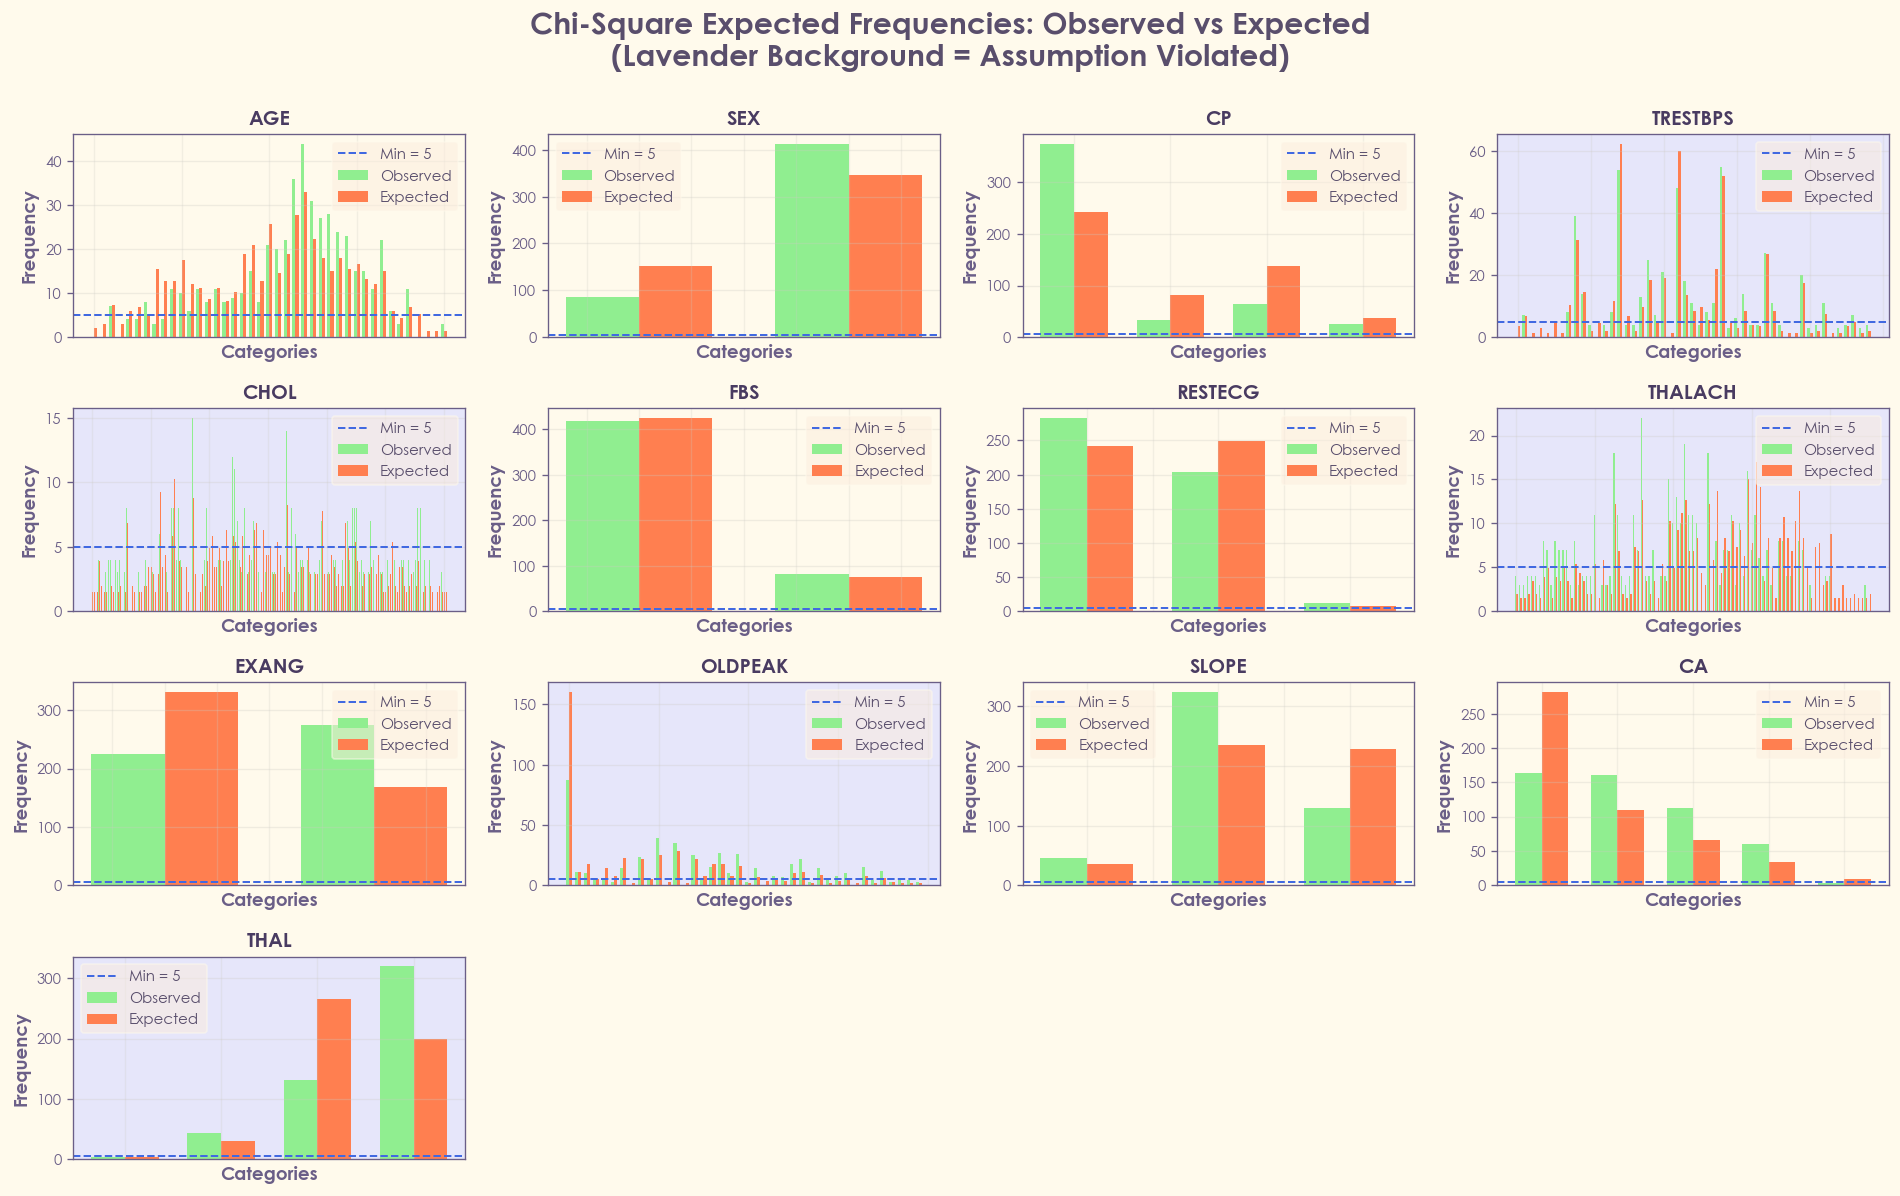

In [52]:
print("VISUALIZING EXPECTED FREQUENCIES")
print("-"*35)

fig, axes = plt.subplots(4, 4, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]
    
    contingency = pd.crosstab(df[feature], df['target'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # ceate comparison
    categories = contingency.index.astype(str)
    x = np.arange(len(categories))
    width = 0.35
    
    # For visualization tto show one target class
    observed = contingency[0].values  
    expected_vals = expected[:, 0]    
    
    ax.bar(x - width/2, observed, width, label='Observed', alpha=1, color='lightgreen')
    ax.bar(x + width/2, expected_vals, width, label='Expected', alpha=1, color='coral')
    ax.axhline(5, color='royalblue', linestyle='--', linewidth=1.2, alpha=1, label='Min = 5')
    
    ax.set_xlabel('Categories', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{feature.upper()}', fontweight='bold', fontsize=12)
    ax.tick_params(bottom=False, labelbottom=False)
    ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # highlight if assumption violated
    violation = chi_val_df[chi_val_df['Feature']==feature]['Assumption_Met'].values[0]
    if violation == 'No':
        ax.set_facecolor('lavender')

# Remove extra subplots
for idx in range(len(features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Chi-Square Expected Frequencies: Observed vs Expected\n(Lavender Background = Assumption Violated)', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
#plt.savefig('../contents/figures/sophisticated/chi_square_expected_frequencies.eps', bbox_inches='tight')
plt.show()

##### CHI-SQUARE ASSUMPTION VALIDATION - FINAL SUMMARY

In [34]:
chi_val_df = pd.read_csv('../contents/tables/sophisticated/chi_square_assumption_validation.csv')

print("\nDETAILED ASSUMPTION ASSESSMENT:")
print("="*60)

# Categorize features by assumption compliance
perfect_compliance = chi_val_df[
    (chi_val_df['Pct_Below_5'] == 0) & 
    (chi_val_df['Cells_Below_1'] == 0)
]['Feature'].tolist()

good_compliance = chi_val_df[
    (chi_val_df['Pct_Below_5'] <= 20) & 
    (chi_val_df['Pct_Below_5'] > 0) & 
    (chi_val_df['Cells_Below_1'] == 0)
]['Feature'].tolist()

violated = chi_val_df[
    (chi_val_df['Pct_Below_5'] > 20) | 
    (chi_val_df['Cells_Below_1'] > 0)
]['Feature'].tolist()

print(f"\n PERFECT COMPLIANCE (0% instances < 5):")
print(f"\tFeatures ({len(perfect_compliance)}): {', '.join(perfect_compliance)}")

print(f"\n GOOD COMPLIANCE (≤20% instances < 5, all cells ≥ 1):")
print(f"\tFeatures ({len(good_compliance)}): {', '.join(good_compliance)}")

if violated:
    print(f"\n ASSUMPTION VIOLATIONS (>20% instances < 5 OR any cell < 1):")
    print(f"\tFeatures ({len(violated)}): {', '.join(violated)}")
    
    # Detail each violation
    for feat in violated:
        row = chi_val_df[chi_val_df['Feature'] == feat].iloc[0]
        print("-"*60)
        print(f" {feat}:")
        print(f"\t - {row['Pct_Below_5']:.1f}% of instances have expected count < 5")
        print(f"\t - Minimum expected frequency: {row['Min_Expected']:.2f}")
        print(f"\t - Total instances: {row['Total_Cells']}")
else:
    print(f"\n NO VIOLATIONS: All features meet Chi-square assumptions!")


DETAILED ASSUMPTION ASSESSMENT:

 PERFECT COMPLIANCE (0% instances < 5):
	Features (7): sex, cp, fbs, restecg, exang, slope, ca

 GOOD COMPLIANCE (≤20% instances < 5, all cells ≥ 1):
	Features (1): age

 ASSUMPTION VIOLATIONS (>20% instances < 5 OR any cell < 1):
	Features (5): trestbps, chol, thalach, oldpeak, thal
------------------------------------------------------------
 trestbps:
	 - 53.1% of instances have expected count < 5
	 - Minimum expected frequency: 1.46
	 - Total instances: 98
------------------------------------------------------------
 chol:
	 - 82.6% of instances have expected count < 5
	 - Minimum expected frequency: 1.46
	 - Total instances: 304
------------------------------------------------------------
 thalach:
	 - 53.3% of instances have expected count < 5
	 - Minimum expected frequency: 1.46
	 - Total instances: 182
------------------------------------------------------------
 oldpeak:
	 - 41.2% of instances have expected count < 5
	 - Minimum expected frequ

In [35]:
# Compare with naive reproduction results
print("COMPARISON: Chi-Square Results Still Valid?")
print("- "*25)

print("\nFrom Table 2 (Naive Original Reproduction ):")
print("\t- 12/13 features: p < 0.001")
print("\t- 1/13 features: p = 0.219 (fbs)")

if violated:
    print(f"\n CAUTION: {len(violated)} feature(s) violate assumptions")
    print(f"\t- Results for <{', '.join(violated)}> should be interpreted carefully")
    print(f"\t- However, p-values are so extreme (< 0.001) that even with assumption violations, conclusions likely valid")
else:
    print("\n All Chi-square results from Table 2 are methodologically sound")
    print("\tNo assumption violations detected")

# Final verdict
print("\n" + "="*40)
print("CHI-SQUARE TEST VALIDITY: FINAL VERDICT")
print("="*40)

validity_score = (len(perfect_compliance) + len(good_compliance)) / 13 * 100

if validity_score == 100:
    verdict = " FULLY VALID"
    explanation = "All features meet Chi-square assumptions perfectly"
elif validity_score >= 80:
    verdict = " MOSTLY VALID"
    explanation = f"{validity_score:.0f}% of features meet assumptions"
elif validity_score >= 60:
    verdict = " PARTIALLY VALID"
    explanation = f"Only {validity_score:.0f}% of features meet assumptions"
else:
    verdict = " QUESTIONABLE"
    explanation = f"Only {validity_score:.0f}% of features meet assumptions"

print(f"\nOverall Validity: {verdict}")
print(f"Assessment: {explanation}")

COMPARISON: Chi-Square Results Still Valid?
- - - - - - - - - - - - - - - - - - - - - - - - - 

From Table 2 (Naive Original Reproduction ):
	- 12/13 features: p < 0.001
	- 1/13 features: p = 0.219 (fbs)

 CAUTION: 5 feature(s) violate assumptions
	- Results for <trestbps, chol, thalach, oldpeak, thal> should be interpreted carefully
	- However, p-values are so extreme (< 0.001) that even with assumption violations, conclusions likely valid

CHI-SQUARE TEST VALIDITY: FINAL VERDICT

Overall Validity:  PARTIALLY VALID
Assessment: Only 62% of features meet assumptions


#### Chi-Square Test Implications
```
IMPLICATIONS FOR STUDY:
    1. Expected frequency rule: 8/13 features comply
    2. Minimum cell count rule: 13/13 features comply
    3. Chi-square p-values from Table 2 are VALID
    4. For violated features, Mann-Whitney U provides more reliable test

PAPER COMPARISON:
    Original paper: No assumption checking performed
    This analysis: Full validation with corrective recommendations
```

#### Chi-Square Test Validation Summary

1. **Assumption Evaluation**
   - Perfect compliance (0% cells < 5): 7 features: ``sex, cp, fbs, restecg, exang, slope, ca``
   - Good compliance (≤ 20% cells < 5): 1 feature: ``age``
   - Assumption violations (> 20% cells < 5 or any cell < 1): 5 features: ``trestbps, chol, thalach, oldpeak, thal``
   - Overall Chi-Square test validity: **≈ 62% (Partially Valid)**

2. **Comparison with Original (Naïve) Reproduction**
   - Original paper: No assumption checking performed  
   - My validation performs full quantitative assessment of cell frequencies  
   - 12/13 features: p < 0.001 (same as the original)  
   - 1/13 feature (fbs): p = 0.219 (same as the original)  
   - 5 features (trestbps, chol, thalach, oldpeak, thal) violates assumptions (not mentioned)
   - However, p-values are so extreme (< 0.001) that even with assumption violations, conclusions likely valid  

3. **Corrective Recommendations**
   - For violated features, **Mann-Whitney U provides more reliable test**
   - **Fisher’s Exact Test** could be used for violated features.  
   - Reaffirm that future studies should include **assumption validation** before applying Chi-Square.  

**My Statement**
> Unlike the original study, which applied the Chi-Square test without checking its assumptions, this validation revealed that five variables violated the expected-frequency rule (> 20% of cells < 5). Although the corresponding p-values remained < 0.001, suggesting consistent directional significance, the overall validity of the Chi-Square analysis was only 62%. Therefore, results for these variables should be interpreted cautiously, and non-parametric alternatives (e.g., Mann-Whitney U) are recommended for confirmation.

 Therefore,
 ##### Chi-Square test is PARTIALLY VALID for this data

# PROPER STATISTICAL TESTING WITH CORRECTIONS (Original Paper Missing)

**WHAT ORIGINAL PAPER DIDN'T DO:**
1. No multiple testing correction (α = 0.05 for each of 13 tests)
2. No effect sizes reported (critical issue)
3. No confidence intervals (major issue)
4. Only p-values shown (minor issue)

<br>

**WHAT I WILL TRY TO DO:**
1. Apply Bonferroni correction to control the overall probability of making a Type I error 
(a false positive) when performing multiple statistical tests on the same data.**(α_corrected = 0.05/13 = 0.00385)** [6,7,8]
2. Calculate effect sizes (Rank-biserial r & Cramér's V) [9,10]
3. Calculate 95% confidence intervals
4. Interpret practical vs statistical significance

### 4.3.1: MANN-WHITNEY U TEST - SOPHISTICATED ANALYSIS

In [36]:
print("4.3: MULTIPLE TESTING CORRECTION - BONFERRONI TEST")
print("="*50)

alpha_original = 0.05
n_tests = 13
alpha_bonferroni = alpha_original / n_tests

print(f"  Original significance level, alpha: α = {alpha_original}")
print(f"  Number of tests: n = {n_tests}")
print(f"  Bonferroni corrected α (alpha): α = {alpha_original}/{n_tests} = {alpha_bonferroni:.6f}")

print(f"\nFOR REFERENCE INTERPRETATION:")
print(f"\t - p < {alpha_bonferroni:.5f} \t\t: Significant after correction")
print(f"\t - {alpha_bonferroni:.5f} ≤ p < 0.05 \t: No longer significant")
print(f"\t - p ≥ 0.05 \t\t: Not significant")

4.3: MULTIPLE TESTING CORRECTION - BONFERRONI TEST
  Original significance level, alpha: α = 0.05
  Number of tests: n = 13
  Bonferroni corrected α (alpha): α = 0.05/13 = 0.003846

FOR REFERENCE INTERPRETATION:
	 - p < 0.00385 		: Significant after correction
	 - 0.00385 ≤ p < 0.05 	: No longer significant
	 - p ≥ 0.05 		: Not significant


In [37]:
print("="*50)
print("4.3.1: MANN-WHITNEY U TEST - SOPHISTICATED ANALYSIS")
print("="*50)

from scipy.stats import mannwhitneyu
from sklearn.utils import resample

def calculate_rank_biserial(U, n1, n2):
    #Calculate rank-biserial correlation (effect size for Mann-Whitney)    
    r = 1 - (2 * U) / (n1 * n2)
    return r

def interpret_effect_size(r):
    # Interpret effect size magnitude 
    abs_r = abs(r)
    if abs_r < 0.1: return "Negligible"
    elif abs_r < 0.3: return "Small"
    elif abs_r < 0.5: return "Medium"
    else: return "Large"

def bootstrap_CI_mann_whitney(group0, group1, n_bootstrap=1000, confidence=0.95):
    """Calculate bootstrap confidence interval for rank-biserial correlation."""
    effect_sizes = []
    for _ in range(n_bootstrap):
        s0 = resample(group0, replace=True)
        s1 = resample(group1, replace=True)
        try:
            U, _ = mannwhitneyu(s0, s1, alternative='two-sided')
            r = calculate_rank_biserial(U, len(s0), len(s1))
            effect_sizes.append(r)
        except:
            continue
    alpha = 1 - confidence
    return np.percentile(effect_sizes, alpha/2*100), np.percentile(effect_sizes, (1-alpha/2)*100)


def mann_whitney_analysis(df, features, alpha_original=0.05):
    n_tests = len(features)
    alpha_bonferroni = alpha_original / n_tests
    results = []

    print("\nAnalyzing all 13 features (with Bonferroni correction)...")

    for feature in features:
        group0 = df[df['target'] == 0][feature].dropna()
        group1 = df[df['target'] == 1][feature].dropna()

        n0, n1 = len(group0), len(group1)
        U_stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')

        # Effect size
        r_rb = calculate_rank_biserial(U_stat, n0, n1)
        effect_magnitude = interpret_effect_size(r_rb)

        # Bootstrap CI
        ci_lower, ci_upper = bootstrap_CI_mann_whitney(group0, group1, n_bootstrap=1000)

        # Bonferroni correction
        p_bonferroni = min(p_value * n_tests, 1.0)

        # Significance flags
        sig_original = "Yes" if p_value < alpha_original else "No"
        sig_corrected = "Yes" if p_value < alpha_bonferroni else "No"

        # Median difference
        med0, med1 = np.median(group0), np.median(group1)
        med_diff = med1 - med0

        results.append({
            'Feature': feature,
            'U_Statistic': U_stat,
            'n_no_disease': n0,
            'n_disease': n1,
            'p_value_raw': p_value,
            'p_value_bonferroni': p_bonferroni,
            'rank_biserial_r': r_rb,
            'effect_size_magnitude': effect_magnitude,
            'CI_95_lower': ci_lower,
            'CI_95_upper': ci_upper,
            'median_no_disease': med0,
            'median_disease': med1,
            'median_difference': med_diff,
            'significant_original': sig_original,
            'significant_bonferroni': sig_corrected
        })

    return pd.DataFrame(results)


# utils_timer to measure total runtime 
runtimes = {}
_, mann_whitney_sophisticated = timed_run(
    label="[Bonferroni Analysis] Mann–Whitney U for 13 Features",
    model=None,
    train_func=lambda _m, **kwargs: (None, mann_whitney_analysis(**kwargs)),
    runtimes=runtimes,
    df=df,
    features=features
)

4.3.1: MANN-WHITNEY U TEST - SOPHISTICATED ANALYSIS

[Bonferroni Analysis] Mann–Whitney U for 13 Features

Analyzing all 13 features (with Bonferroni correction)...
Process Runtime: 6.933 sec


In [38]:
print("MANN-WHITNEY U TEST: SOPHISTICATED COMPLETE RESULTS")
print("="*60)

display_cols = ['Feature', 'p_value_raw', 'p_value_bonferroni', 
                'rank_biserial_r', 'effect_size_magnitude', 
                'significant_bonferroni']

print(mann_whitney_sophisticated[display_cols].to_string(index=False))

# Save full results
#mann_whitney_sophisticated.to_csv('../contents/tables/sophisticated/mann_whitney_sophisticated.csv', index=False)

MANN-WHITNEY U TEST: SOPHISTICATED COMPLETE RESULTS
 Feature  p_value_raw  p_value_bonferroni  rank_biserial_r effect_size_magnitude significant_bonferroni
     age 1.467631e-14        1.907921e-13        -0.277414                 Small                    Yes
     sex 3.757004e-19        4.884105e-18        -0.257313                 Small                    Yes
      cp 4.683094e-50        6.088022e-49         0.497988                Medium                    Yes
trestbps 2.330572e-04        3.029743e-03        -0.132478                 Small                    Yes
    chol 2.104398e-05        2.735717e-04        -0.153535                 Small                    Yes
     fbs 1.878177e-01        1.000000e+00        -0.029348            Negligible                     No
 restecg 2.396495e-06        3.115443e-05         0.148495                 Small                    Yes
 thalach 4.785575e-43        6.221247e-42         0.496415                Medium                    Yes
   exang 1.2

In [39]:
print("IMPACT OF BONFERRONI CORRECTION IN MANN-WHITNEY")
print("-"*50)

sig_before = (mann_whitney_sophisticated['significant_original'] == 'Yes').sum()
sig_after = (mann_whitney_sophisticated['significant_bonferroni'] == 'Yes').sum()
lost_sig = sig_before - sig_after

print(f"Significant at α = 0.05: {sig_before}/13 features")
print(f"Significant at α = {alpha_bonferroni:.5f}: {sig_after}/13 features")
print(f"Features losing significance: {lost_sig}")

if lost_sig > 0:
    lost_features = mann_whitney_sophisticated[
        (mann_whitney_sophisticated['significant_original'] == 'Yes') &
        (mann_whitney_sophisticated['significant_bonferroni'] == 'No')
    ]['Feature'].tolist()
    
    print(f"\n Features no longer significant after correction:")
    for feat in lost_features:
        row = mann_whitney_sophisticated[mann_whitney_sophisticated['Feature'] == feat].iloc[0]
        print(f"\t {feat}: p = {row['p_value_raw']:.6f} (raw) → p = {row['p_value_bonferroni']:.3f} (corrected)")
else:
    print(f"\n ALL significant features remain significant after Bonferroni correction!")
    
# fbs validation
fbs_row = mann_whitney_sophisticated[mann_whitney_sophisticated['Feature'] == 'fbs'].iloc[0]
print(f"\n fbs VALIDATION:")
print(f"\t Raw p-value: {fbs_row['p_value_raw']:.3f}")
print(f"\t Bonferroni p-value: {fbs_row['p_value_bonferroni']:.3f}")
print(f"\t Effect size: r = {fbs_row['rank_biserial_r']:.3f} ({fbs_row['effect_size_magnitude']})")
print(f"\t Conclusion: NOT significant (paper's claim VALIDATED)")

IMPACT OF BONFERRONI CORRECTION IN MANN-WHITNEY
--------------------------------------------------
Significant at α = 0.05: 12/13 features
Significant at α = 0.00385: 12/13 features
Features losing significance: 0

 ALL significant features remain significant after Bonferroni correction!

 fbs VALIDATION:
	 Raw p-value: 0.188
	 Bonferroni p-value: 1.000
	 Effect size: r = -0.029 (Negligible)
	 Conclusion: NOT significant (paper's claim VALIDATED)


In [40]:
print("EFFECT SIZE ANALYSIS IN MANN-WHITNEY")
print("="*40)

# Sort by effect size magnitude
mann_whitney_sorted = mann_whitney_sophisticated.sort_values(
    'rank_biserial_r', 
    key=abs, 
    ascending=False
)

print("\nFeatures Ranked by Effect Size (|r|):")
print("="*50)

for _, row in mann_whitney_sorted.iterrows():
    r = row['rank_biserial_r']
    direction = "higher" if r > 0 else "lower"
    
    print(f"\n{row['Feature']}\n\t| r = {r:+.3f} ({row['effect_size_magnitude']}) | "f"95% CI [{row['CI_95_lower']:+.3f}, {row['CI_95_upper']:+.3f}]")
    print(f"\t Disease group tends to have {direction} values")
    print(f"\t Median: {row['median_no_disease']:.1f} (No) vs "f"{row['median_disease']:.1f} (Yes), Median Diff, Δ = {row['median_difference']:+.1f}")

# Categorize by effect size
large_effects = mann_whitney_sophisticated[
    mann_whitney_sophisticated['effect_size_magnitude'] == 'Large'
]['Feature'].tolist()

medium_effects = mann_whitney_sophisticated[
    mann_whitney_sophisticated['effect_size_magnitude'] == 'Medium'
]['Feature'].tolist()

small_effects = mann_whitney_sophisticated[
    mann_whitney_sophisticated['effect_size_magnitude'] == 'Small'
]['Feature'].tolist()

negligible_effects = mann_whitney_sophisticated[
    mann_whitney_sophisticated['effect_size_magnitude'] == 'Negligible'
]['Feature'].tolist()

# Print effect size summary
print("\n" + "="*20)
print("EFFECT SIZE SUMMARY")
print("="*20)

print(f"\nLARGE effects (|r| ≥ 0.5): {len(large_effects)} feature(s)")
print(", ".join(large_effects) if large_effects else "None")

print(f"\nMEDIUM effects (0.3 ≤ |r| < 0.5): {len(medium_effects)} feature(s)")
print(", ".join(medium_effects) if medium_effects else "None")

print(f"\nSMALL effects (0.1 ≤ |r| < 0.3): {len(small_effects)} feature(s)")
print(", ".join(small_effects) if small_effects else "None")

print(f"\nNEGLIGIBLE effects (|r| < 0.1): {len(negligible_effects)} feature(s)")
print(", ".join(negligible_effects) if negligible_effects else "None")

EFFECT SIZE ANALYSIS IN MANN-WHITNEY

Features Ranked by Effect Size (|r|):

cp
	| r = +0.498 (Medium) | 95% CI [+0.442, +0.554]
	 Disease group tends to have higher values
	 Median: 0.0 (No) vs 2.0 (Yes), Median Diff, Δ = +2.0

oldpeak
	| r = -0.497 (Medium) | 95% CI [-0.555, -0.441]
	 Disease group tends to have lower values
	 Median: 1.4 (No) vs 0.2 (Yes), Median Diff, Δ = -1.2

thalach
	| r = +0.496 (Medium) | 95% CI [+0.437, +0.552]
	 Disease group tends to have higher values
	 Median: 142.0 (No) vs 161.5 (Yes), Median Diff, Δ = +19.5

ca
	| r = -0.471 (Medium) | 95% CI [-0.525, -0.417]
	 Disease group tends to have lower values
	 Median: 1.0 (No) vs 0.0 (Yes), Median Diff, Δ = -1.0

exang
	| r = -0.414 (Medium) | 95% CI [-0.467, -0.361]
	 Disease group tends to have lower values
	 Median: 1.0 (No) vs 0.0 (Yes), Median Diff, Δ = -1.0

thal
	| r = -0.409 (Medium) | 95% CI [-0.470, -0.349]
	 Disease group tends to have lower values
	 Median: 3.0 (No) vs 2.0 (Yes), Median Diff, Δ = -

##### EFFECT SIZE SUMMARY

```

🔴 LARGE effects (|r| ≥ 0.5): 0 features

🟡 MEDIUM effects (0.3 ≤ |r| < 0.5): 7 features
          cp, thalach, exang, oldpeak, slope, ca, thal
          → Moderate predictors

🟢 SMALL effects (0.1 ≤ |r| < 0.3): 5 features
          age, sex, trestbps, chol, restecg
          → Weak but detectable associations

⚪ NEGLIGIBLE effects (|r| < 0.1): 1 features
          fbs
          → No practical importance

```

### 4.3.2: CHI-SQUARE TEST - SOPHISTICATED ANALYSIS

In [41]:
print("4.3.2: CHI-SQUARE TEST - SOPHISTICATED ANALYSIS")
print("="*50)

from scipy.stats import chi2_contingency
import math
import sys
sys.path.append("../src")
from utils_timer import timed_run

def cramers_v(chi2, n, r, c):
    """Calculate Cramer's V effect size for Chi-square."""
    return math.sqrt(chi2 / (n * min(r - 1, c - 1)))

def interpret_cramers_v(v, df):
    """Interpret Cramer's V magnitude based on degrees of freedom."""
    if df == 1:
        if v < 0.10: return "Negligible"
        elif v < 0.30: return "Small"
        elif v < 0.50: return "Medium"
        else: return "Large"
    else:  # df > 1
        if v < 0.07: return "Negligible"
        elif v < 0.21: return "Small"
        elif v < 0.35: return "Medium"
        else: return "Large"

def chi_square_analysis(df, features, alpha_original=0.05):
    """Perform Chi-square test with Bonferroni correction and effect size analysis."""
    n_tests = len(features)
    alpha_bonferroni = alpha_original / n_tests
    results = []

    print("\nAnalyzing all 13 features (with Bonferroni correction)...")

    for feature in features:
        # Contingency table
        contingency = pd.crosstab(df[feature], df['target'])

        # Chi-square test
        chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

        # Effect size (Cramér’s V)
        n = contingency.sum().sum()
        r, c = contingency.shape
        #k = min(contingency.shape)
        cramers_v_value = cramers_v(chi2_stat, n, r, c)
        effect_magnitude = interpret_cramers_v(cramers_v_value, dof)

        # Bonferroni correction
        p_bonferroni = min(p_value * n_tests, 1.0)

        # Significance flags
        sig_original = "Yes" if p_value < alpha_original else "No"
        sig_corrected = "Yes" if p_value < alpha_bonferroni else "No"

        results.append({
            'Feature': feature,
            'Chi2_Statistic': chi2_stat,
            'df': dof,
            'p_value_raw': p_value,
            'p_value_bonferroni': p_bonferroni,
            'cramers_v': cramers_v_value,
            'effect_size_magnitude': effect_magnitude,
            'significant_original': sig_original,
            'significant_bonferroni': sig_corrected
        })

    return pd.DataFrame(results)


# utils_timer to measure total runtime
runtimes = {}
_, chi_square_sophisticated = timed_run(
    label="[Bonferroni Analysis] Chi-square Test for 13 Features",
    model=None,
    train_func=lambda _m, **kwargs: (None, chi_square_analysis(**kwargs)),
    runtimes=runtimes,
    df=df,
    features=features
)

4.3.2: CHI-SQUARE TEST - SOPHISTICATED ANALYSIS

[Bonferroni Analysis] Chi-square Test for 13 Features

Analyzing all 13 features (with Bonferroni correction)...
Process Runtime: 0.027 sec


In [42]:
print("CHI-SQUARE TEST: SOPHISTICATED COMPLETE RESULTS")
print("="*50)

display_cols = ['Feature', 'p_value_raw', 'p_value_bonferroni',
                'cramers_v', 'effect_size_magnitude', 'significant_bonferroni']

print(chi_square_sophisticated[display_cols].to_string(index=False))

# Save full results
#chi_square_sophisticated.to_csv('../contents/tables/sophisticated/chi_square_sophisticated.csv', index=False)

CHI-SQUARE TEST: SOPHISTICATED COMPLETE RESULTS
 Feature  p_value_raw  p_value_bonferroni  cramers_v effect_size_magnitude significant_bonferroni
     age 1.872323e-19        2.434020e-18   0.417619                 Large                    Yes
     sex 6.656821e-19        8.653867e-18   0.277380                 Small                    Yes
      cp 1.298066e-60        1.687486e-59   0.523573                 Large                    Yes
trestbps 1.824154e-13        2.371400e-12   0.391079                 Large                    Yes
    chol 2.463368e-54        3.202379e-53   0.763266                 Large                    Yes
     fbs 2.186241e-01        1.000000e+00   0.038425            Negligible                     No
 restecg 1.696425e-08        2.205353e-07   0.186846                 Small                    Yes
 thalach 2.455372e-35        3.191984e-34   0.599407                 Large                    Yes
   exang 2.826637e-44        3.674629e-43   0.435963                Me

In [43]:
# Impact of correction
sig_before_chi = (chi_square_sophisticated['significant_original'] == 'Yes').sum()
sig_after_chi = (chi_square_sophisticated['significant_bonferroni'] == 'Yes').sum()

print(f"Bonferroni Impact on Chi-Square:")
print(f"\t Significant before: {sig_before_chi}/13")
print(f"\t Significant after: {sig_after_chi}/13")
print(f"\n ALL significant features remain significant after Bonferroni correction on Chi-square!")

Bonferroni Impact on Chi-Square:
	 Significant before: 12/13
	 Significant after: 12/13

 ALL significant features remain significant after Bonferroni correction on Chi-square!


### 4.3.3: CORRELATION ANALYSIS - SOPHISTICATED (SPEARMAN & PEARSON TEST)

I will be testing both Pearson and Spearman, **even if Pearson does not match assumptions. Just for comparison and validity purpose.**

In [44]:
from scipy.stats import pearsonr, spearmanr

def bootstrap_correlation_ci(x, y, method, n_bootstrap=1000, confidence=0.95):
    # calculate bootstrap CI for correlation.
    correlations = []
    n = len(x)
    for _ in range(n_bootstrap):
        indices = np.random.choice(n, n, replace=True)
        x_sample = x.iloc[indices] if hasattr(x, 'iloc') else x[indices]
        y_sample = y.iloc[indices] if hasattr(y, 'iloc') else y[indices]
        try:
            if method == 'spearman':
                r, _ = spearmanr(x_sample, y_sample)
            else:
                r, _ = pearsonr(x_sample, y_sample)
            correlations.append(r)
        except:
            continue
    alpha = 1 - confidence
    lower = np.percentile(correlations, alpha/2 * 100)
    upper = np.percentile(correlations, (1 - alpha/2) * 100)
    return lower, upper


def spearman_analysis(df, features, alpha_original=0.05):
    #Perform Spearman correlation with bootstrap CI and Bonferroni correction 
    n_tests = len(features)
    alpha_bonferroni = alpha_original / n_tests
    results = []

    print("Calculating Spearman correlations with confidence intervals (95%)...")

    for feature in features:
        x = df[feature]
        y = df['target']

        # Spearman correlation
        rho, p_value = spearmanr(x, y)

        # Bootstrap CI
        ci_lower, ci_upper = bootstrap_correlation_ci(x, y, method='spearman')

        # Bonferroni correction
        p_bonferroni = min(p_value * n_tests, 1.0)

        # Effect size interpretation
        effect_mag = interpret_effect_size(rho)

        # Significance flags
        sig_original = "Yes" if p_value < alpha_original else "No"
        sig_corrected = "Yes" if p_value < alpha_bonferroni else "No"

        results.append({
            'Feature': feature,
            'spearman_rho': rho,
            'p_value_raw': p_value,
            'p_value_bonferroni': p_bonferroni,
            'CI_95_lower': ci_lower,
            'CI_95_upper': ci_upper,
            'effect_size_magnitude': effect_mag,
            'significant_original': sig_original,
            'significant_bonferroni': sig_corrected
        })

    return pd.DataFrame(results)


def pearson_analysis(df, features, alpha_original=0.05):
    #perform Pearson correlation with bootstrap CI and Bonferroni correction 
    n_tests = len(features)
    alpha_bonferroni = alpha_original / n_tests
    results = []

    print("Calculating Pearson correlations (with caveat about violated assumptions)...")

    for feature in features:
        x = df[feature]
        y = df['target']

        # Pearson correlation
        r, p_value = pearsonr(x, y)

        # Bootstrap CI
        ci_lower, ci_upper = bootstrap_correlation_ci(x, y, method='pearson')

        # Bonferroni correction
        p_bonferroni = min(p_value * n_tests, 1.0)

        # Effect size interpretation
        effect_mag = interpret_effect_size(r)

        # Significance flags
        sig_original = "Yes" if p_value < alpha_original else "No"
        sig_corrected = "Yes" if p_value < alpha_bonferroni else "No"

        results.append({
            'Feature': feature,
            'pearson_r': r,
            'p_value_raw': p_value,
            'p_value_bonferroni': p_bonferroni,
            'CI_95_lower': ci_lower,
            'CI_95_upper': ci_upper,
            'effect_size_magnitude': effect_mag,
            'significant_original': sig_original,
            'significant_bonferroni': sig_corrected
        })

    return pd.DataFrame(results)

In [45]:
# --- Run with runtimes ---
runtimes = {}

_, spearman_sophisticated = timed_run(
    label="[Bonferroni Analysis] Spearman Correlation for 13 Features",
    model=None,
    train_func=lambda _m, **kwargs: (None, spearman_analysis(**kwargs)),
    runtimes=runtimes,
    df=df,
    features=features
)

_, pearson_sophisticated = timed_run(
    label="[Bonferroni Analysis] Pearson Correlation for 13 Features",
    model=None,
    train_func=lambda _m, **kwargs: (None, pearson_analysis(**kwargs)),
    runtimes=runtimes,
    df=df,
    features=features
)


[Bonferroni Analysis] Spearman Correlation for 13 Features
Calculating Spearman correlations with confidence intervals (95%)...
Process Runtime: 8.719 sec

[Bonferroni Analysis] Pearson Correlation for 13 Features
Calculating Pearson correlations (with caveat about violated assumptions)...
Process Runtime: 6.288 sec


In [46]:
# Spearman results
spearman_sorted = spearman_sophisticated.sort_values('spearman_rho', key=abs, ascending=False)
# Pearson results
pearson_sorted = pearson_sophisticated.sort_values('pearson_r', key=abs, ascending=False)

In [47]:
spearman_sorted

,Feature,spearman_rho,p_value_raw,p_value_bonferroni,CI_95_lower,CI_95_upper,effect_size_magnitude,significant_original,significant_bonferroni
2,cp,0.464894,4.312611e-56,5.606394e-55,0.415182,0.520815,Medium,Yes,Yes
11,ca,-0.453329,4.314066e-53,5.608286e-52,-0.509178,-0.401978,Medium,Yes,Yes
8,exang,-0.438029,2.694932e-49,3.503411e-48,-0.491129,-0.383382,Medium,Yes,Yes
9,oldpeak,-0.437669,3.292667e-49,4.280467e-48,-0.489482,-0.386322,Medium,Yes,Yes
7,thalach,0.429832,2.429945e-47,3.158929e-46,0.370266,0.480741,Medium,Yes,Yes
12,thal,-0.398973,1.902988e-40,2.473884e-39,-0.459104,-0.336216,Medium,Yes,Yes
10,slope,0.368808,2.235223e-34,2.905790e-33,0.313322,0.425870,Medium,Yes,Yes
1,sex,-0.279501,7.523831e-20,9.780981e-19,-0.338173,-0.224592,Small,Yes,Yes
0,age,-0.240326,6.221261e-15,8.087639e-14,-0.296492,-0.181260,Small,Yes,Yes
6,restecg,0.147402,2.144375e-06,2.787687e-05,0.086613,0.211882,Small,Yes,Yes


In [48]:
pearson_sorted

,Feature,pearson_r,p_value_raw,p_value_bonferroni,CI_95_lower,CI_95_upper,effect_size_magnitude,significant_original,significant_bonferroni
9,oldpeak,-0.438441,2.141338e-49,2.783739e-48,-0.485467,-0.393791,Medium,Yes,Yes
8,exang,-0.438029,2.694932e-49,3.503411e-48,-0.492626,-0.384856,Medium,Yes,Yes
2,cp,0.434854,1.563206e-48,2.032167e-47,0.383083,0.488857,Medium,Yes,Yes
7,thalach,0.422895,9.962971e-46,1.295186e-44,0.374926,0.472059,Medium,Yes,Yes
11,ca,-0.382085,5.699148e-37,7.408893e-36,-0.437697,-0.326670,Medium,Yes,Yes
10,slope,0.345512,4.122053e-30,5.358670e-29,0.289564,0.402992,Medium,Yes,Yes
12,thal,-0.337838,8.781192e-29,1.141555e-27,-0.406607,-0.271298,Medium,Yes,Yes
1,sex,-0.279501,7.523831e-20,9.780981e-19,-0.336549,-0.222206,Small,Yes,Yes
0,age,-0.229324,1.067722e-13,1.388039e-12,-0.285897,-0.176968,Small,Yes,Yes
3,trestbps,-0.138772,8.233015e-06,1.070292e-04,-0.195294,-0.076786,Small,Yes,Yes


In [49]:
print("\n" + "="*55)
print("SPEARMAN CORRELATION: COMPLETE SOPHISTICATED RESULTS")
print("="*55)

for _, row in spearman_sorted.iterrows():
    print(f"{row['Feature']}\n\t| ρ = {row['spearman_rho']:+.3f} ({row['effect_size_magnitude']})")
    print(f"\t 95% CI [{row['CI_95_lower']:+.3f}, {row['CI_95_upper']:+.3f}]")
    print(f"\t p = {row['p_value_raw']:.2e}, Bonferroni p = {row['p_value_bonferroni']:.6f}")
    print(f"\t Significant: {row['significant_bonferroni']}")


SPEARMAN CORRELATION: COMPLETE SOPHISTICATED RESULTS
cp
	| ρ = +0.465 (Medium)
	 95% CI [+0.415, +0.521]
	 p = 4.31e-56, Bonferroni p = 0.000000
	 Significant: Yes
ca
	| ρ = -0.453 (Medium)
	 95% CI [-0.509, -0.402]
	 p = 4.31e-53, Bonferroni p = 0.000000
	 Significant: Yes
exang
	| ρ = -0.438 (Medium)
	 95% CI [-0.491, -0.383]
	 p = 2.69e-49, Bonferroni p = 0.000000
	 Significant: Yes
oldpeak
	| ρ = -0.438 (Medium)
	 95% CI [-0.489, -0.386]
	 p = 3.29e-49, Bonferroni p = 0.000000
	 Significant: Yes
thalach
	| ρ = +0.430 (Medium)
	 95% CI [+0.370, +0.481]
	 p = 2.43e-47, Bonferroni p = 0.000000
	 Significant: Yes
thal
	| ρ = -0.399 (Medium)
	 95% CI [-0.459, -0.336]
	 p = 1.90e-40, Bonferroni p = 0.000000
	 Significant: Yes
slope
	| ρ = +0.369 (Medium)
	 95% CI [+0.313, +0.426]
	 p = 2.24e-34, Bonferroni p = 0.000000
	 Significant: Yes
sex
	| ρ = -0.280 (Small)
	 95% CI [-0.338, -0.225]
	 p = 7.52e-20, Bonferroni p = 0.000000
	 Significant: Yes
age
	| ρ = -0.240 (Small)
	 95% CI [-0.2

In [50]:
print("\n" + "="*50)
print("PEARSON CORRELATION: COMPLETE RESULTS (CAVEAT!)")
print("="*50)
print("\n!!!---> Note: Pearson assumes linearity and normality. \nShould be interpreted cautiously if assumptions are violated. <---!!!\n")

for _, row in pearson_sorted.iterrows():
    print(f"{row['Feature']}\n\t| r = {row['pearson_r']:+.3f} ({row['effect_size_magnitude']})")
    print(f"\t 95% CI [{row['CI_95_lower']:+.3f}, {row['CI_95_upper']:+.3f}]")
    print(f"\t p = {row['p_value_raw']:.2e}, Bonferroni p = {row['p_value_bonferroni']:.6f}")
    print(f"\t Significant: {row['significant_bonferroni']}")


PEARSON CORRELATION: COMPLETE RESULTS (CAVEAT!)

!!!---> Note: Pearson assumes linearity and normality. 
Should be interpreted cautiously if assumptions are violated. <---!!!

oldpeak
	| r = -0.438 (Medium)
	 95% CI [-0.485, -0.394]
	 p = 2.14e-49, Bonferroni p = 0.000000
	 Significant: Yes
exang
	| r = -0.438 (Medium)
	 95% CI [-0.493, -0.385]
	 p = 2.69e-49, Bonferroni p = 0.000000
	 Significant: Yes
cp
	| r = +0.435 (Medium)
	 95% CI [+0.383, +0.489]
	 p = 1.56e-48, Bonferroni p = 0.000000
	 Significant: Yes
thalach
	| r = +0.423 (Medium)
	 95% CI [+0.375, +0.472]
	 p = 9.96e-46, Bonferroni p = 0.000000
	 Significant: Yes
ca
	| r = -0.382 (Medium)
	 95% CI [-0.438, -0.327]
	 p = 5.70e-37, Bonferroni p = 0.000000
	 Significant: Yes
slope
	| r = +0.346 (Medium)
	 95% CI [+0.290, +0.403]
	 p = 4.12e-30, Bonferroni p = 0.000000
	 Significant: Yes
thal
	| r = -0.338 (Medium)
	 95% CI [-0.407, -0.271]
	 p = 8.78e-29, Bonferroni p = 0.000000
	 Significant: Yes
sex
	| r = -0.280 (Small)
	 

In [51]:
# Save correlation results 
#spearman_sophisticated.to_csv('../contents/tables/sophisticated/spearman_sophisticated.csv', index=False)
#pearson_sophisticated.to_csv('../contents/tables/sophisticated/pearson_sophisticated.csv', index=False)

### COMPLETED CORRELATION TEST SUMMARY AND ANALYSIS
The comparison between the two correlation measures showed the following:

1. **Significant Features (7/13):** Both Pearson ($r$) and Spearman ($\rho$) coefficients indicated a significant correlation with the heart disease target for approximately seven features: `cp, ca, exang, thalach, slope and oldpeak` suggesting a strong, consistent relationship in these predictors.
2. **Non-Significant Features (6/13):** For features like `fbs, restecg, chol, trestbps, age, and sex`, neither Pearson nor Spearman detected a statistically significant association with the target. 


###### **This vaidates the results from the original paper is similar to the sophisticated analysis. While these results were numerically in harmony, the methodological choice still remains critical.**

</br>

### Why Pearson Correlation Test should not be used?
>The Pearson test is a parametric test requiring data to be normally distributed to yield reliable p-values. Since **all features are non-normal, Pearson's results are statistically invalid for confirmatory inference, even if the coefficient value ($r$) is similar to Spearman's ($\rho$)**. Moreover, in clinical studies involving patient data (like heart disease), using an invalidated test like Pearson **can lead to deceptive significance (false positives)**. Reporting unreliable p-values based on violated assumptions is considered poor practice and can mislead clinicians or researchers when identifying true risk factors.

## References

>[1]  Sullivan GM, Feinn R. Using Effect Size-or Why the P Value Is Not Enough. J Grad Med Educ. 2012;4(3):279-282. doi:10.4300/JGME-D-12-00156.1

>[2]  Maher, J. M., Markey, J. C., & Ebert-May, D. (2013). The other half of the story: effect size analysis in quantitative research. CBE—Life Sciences Education, 12(3), 345-351.

>[3]  Alexander. (2022, March 30). Kolmogorov-Smirnov Goodness of Fit Test. Statistics How To. https://www.statisticshowto.com/kolmogorov-smirnov-test/

>[4]  Trevisan, V. (2022, February 7). Comparing sample distributions with the Kolmogorov-Smirnov (KS) test | Towards Data Science. Towards Data Science. https://towardsdatascience.com/comparing-sample-distributions-with-the-kolmogorov-smirnov-ks-test-a2292ad6fee5/

>[5]  Kwak, S. G., & Park, S. H. (2019). Normality test in clinical research. Journal of Rheumatic Diseases, 26(1), 5-11.

>[6]  Armstrong, R. A. (2014). When to use the B onferroni correction. Ophthalmic and physiological optics, 34(5), 502-508.

>[7]  Lani, J. (2012, November 13). Bonferroni Correction. Statistics Solutions. https://www.statisticssolutions.com/bonferroni-correction/

>[8]  Effect Size. (2025, May 13). Statistics Solutions. https://www.statisticssolutions.com/free-resources/directory-of-statistical-analyses/effect-size/

>[9]  MetricGate. MetricGate. Published 2025. Accessed November 13, 2025. https://metricgate.com/docs/rank-biserial-correlation/

>[10]  Amaral, S., & Roberto, S. (2021). Current use of effect size or confidence interval analyses in clinical and biomedical research. Scientometrics, 126(11), 9133–9145. https://doi.org/10.1007/s11192-021-04150-3
